<a href="https://colab.research.google.com/github/Bendrox/Legal_API_LegiFrance/blob/main/Explore_L%C3%A9giFrance_API_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>







<div style="text-align: center;">
    <img src="https://piste.gouv.fr/images/logo-Piste-large.png" alt="Logo Piste" width="400" />
</div>








# Projet X : Exploitation de l'API LégiFrance





#I. Introduction
Ce projet explore les fonctionnalités de l'API Légifrance sur la plateforme PISTE. Il vise à montrer comment accéder, manipuler et exploiter des données juridiques publiques en utilisant Python et les requêtes de l'API.

Piste website:  https://piste.gouv.fr/




#II.  Project Goals
- Apprendre à interagir avec les requetes API LégiFrance PISTE.
- Extraire de multiples textes juridiques selon différents critères.
- Pouvoir suivre les évolutions réglemenataires


#III. API Overview




Au total : ~70 requêtes API classées en 6 grandes familles.





### Familles de requêtes développées



#### 1. **Consult Controller**
- **Objectif** : Récupérer des informations spécifiques législatives ou réglementaires (textes, articles, etc.).
- **Fonctionnalités** :
  - Obtenir un article spécifique via son `id`.
  - Récupérer des détails sur une loi ou un texte réglementaire précis.



#### 2. **Chrono Controller**
- **Objectif** : Accéder à l'historique et à l'évolution chronologique des textes.
- **Fonctionnalité** :
  - Suivre les modifications ou révisions d’un texte au fil du temps.



#### 3. **List Controller**
- **Objectif** : Fournir des listes de documents basées sur des critères spécifiques.
- **Fonctionnalités** :
  - Lister tous les articles d'un code particulier.
  - Récupérer la liste des décrets associés à une loi.





### Familles de requêtes non développées



#### 4. **Suggest Controller**
- **Objectif** : Fournir des suggestions basées sur une recherche partielle.
- **Fonctionnalités** :
  - Rechercher un texte via des mots-clés ou des fragments.



#### 5. **Misc Controller**
- **Objectif** : Récupérer des métadonnées ou des informations auxiliaires.
- **Fonctionnalités** :
  - Obtenir des données complémentaires sur les textes ou documents.



#### 6. **Search Controller**
- **Objectif** : Effectuer des recherches globales sur les textes, articles, codes, etc., en fonction de mots-clés ou d'autres critères.
- **Fonctionnalités** :
  - Rechercher des textes ou articles pertinents par mots-clés.
  - Filtrer les résultats en fonction de critères spécifiques.


#IV. Global architecture

To be completed

#V. Future Enhancements (to-do List)
- [x] API calls
- [x] Data preparation
- [ ] Designing unique global architecture
- [ ] Function definition
- [ ] Streamlit Interface design
- [ ] RAG


#VI. Solution:


# 1 - LégiFrance API co

In [ ]:
import getpass
client_id = getpass.getpass("Enter the client_id Key: ")

Enter the client_id Key: ··········


In [ ]:
client_secret = getpass.getpass("Enter the client_secret Key: ")

Enter the client_secret Key: ··········


## 1.1 - API Get access token

In [ ]:
import sys
print(sys.version)

3.10.12 (main, Sep 11 2024, 15:47:36) [GCC 11.4.0]


In [ ]:
pip install python-dotenv

In [ ]:
import os
from dotenv import load_dotenv
import requests
from requests_oauthlib import OAuth2Session
import json

In [ ]:
#option 2:
import requests


# URL pour obtenir le jeton
token_url = 'https://sandbox-oauth.piste.gouv.fr/api/oauth/token'

# inject cred for token request
token_data = {
    'grant_type': 'client_credentials',
    'client_id': client_id,
    'client_secret': client_secret,
    'scope': 'openid'
}

# run the request
response = requests.post(token_url, data=token_data)
response.raise_for_status()  # vérif  erreurs

# récup  jeton
token_info = response.json()
access_token = token_info['access_token']

## 1.2 - Ping/Pong request Test

In [ ]:
# Call 1 : Ping/Pong
headers_1=  {
		'accept': 'text/plain',
		'Authorization': 'Bearer ' + access_token
	}

output = requests.get("https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/ping",
                       headers = headers_1).text

display(output)

'pong'

# 2 - API calls



## 2.1 - Consult Controller

### 2.1.1 - Contenu Article - avec Eli (Fait)






Eli - Identifiant Européen de la Législation:

- Permet d'identifier de façon unique les documents législatifs et réglementaires au sein de la base de données de Légifrance.

- Déclinaison :

/eli : Préfixe indiquant qu'il s'agit d'un identifiant ELI.

/decret : Type de texte (ici un décret) peut aussi être un arrêté, une loi, ou d'autres types d'actes normatifs...

/2021/7/13 : Date de publication ou adoption (13 juillet 2021 dans cet exemple).

/PRMD2117108D : Numéro unique du décret

/jo : Indication que le document a été publié dans le Journal Officiel.

/article_1 : Référence à un article spécifique dans le document (ici l'article 1).


#### 2.1.1.1 - Requête


In [ ]:
# Call 2: Contenu article
headers_2 = {
    "accept": "application/json",
    "Content-Type": "application/json",
    'Authorization': 'Bearer ' + access_token}

data = {
    "idEliOrAlias": "/eli/decret/2021/7/13/PRMD2117108D/jo/article_1"
}

url= "https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/getArticleWithIdEliOrAlias"
response = requests.post(url,
                         headers=headers_2,
                         json=data) # dictionnaire data converti en JSON
                                    #inject request

#### 2.1.1.2 - Output data prep


In [ ]:
response_json = response.json()
display(response_json)

In [ ]:
response_json['article']['context']['titresTM']
# input : Eli
# reste a dev : structure (ex: livre , chapitre, section ...)
# dates valeur abérante

[{'debut': '2999-01-01',
  'fin': '2999-01-01',
  'titre': 'Chapitre Ier : Attributions du secrétaire général de la défense et de la sécurité nationale en matière de lutte contre les ingérences numériques étrangères',
  'xPath': '/ARTICLE/CONTEXTE/TEXTE/TM/TITRE_TM',
  'cid': 'JORFSCTA000043788368',
  'id': 'JORFSCTA000043788368',
  'etat': ''}]

In [ ]:
response_json['article']['textTitles'][1]['etat']

'VIGUEUR'

In [ ]:
response_json['article']['etat']

'INITIALE'

In [ ]:
response_json['article']['id']  #JORF

'JORFARTI000043788371'

In [ ]:
response_json['article']['textTitles'][1]["titreLong"] # Ok demande DAJ

"Décret n° 2021-922 du 13 juillet 2021 portant création, auprès du secrétaire général de la défense et de la sécurité nationale, d'un service à compétence nationale dénommé « service de vigilance et de protection contre les ingérences numériques étrangères »"

In [ ]:
response_json['article']['idEliAlias'] # Ok demande DAJ pour N°Article

'/eli/decret/2021/7/13/2021-922/jo/article_1'

In [ ]:
response_json['article']['texte']

"Le code de la défense est ainsi modifié : 1° L'article R.* 1132-3 est complété par un 9° ainsi rédigé : « 9° En liaison avec les départements ministériels concernés, il identifie les opérations impliquant, de manière directe ou indirecte, un Etat étranger ou une entité non étatique étrangère, et visant à la diffusion artificielle ou automatisée, massive et délibérée, par le biais d'un service de communication au public en ligne, d'allégations ou imputations de faits manifestement inexactes ou trompeuses de nature à porter atteinte aux intérêts fondamentaux de la Nation. Il anime et coordonne les travaux interministériels en matière de protection contre ces opérations. » ; 2° La section 1 du chapitre II du titre III du livre premier de la première partie est complétée par un article D. 1132-8 ainsi rédigé : « Art. D. 1132-8. - Pour assurer les missions qui lui sont assignées au 9° de l'article R.* 1132-3, le secrétaire général de la défense et de la sécurité nationale dispose du servic

### 2.1.2 - Contenu texte type CODE  /consult/code (Fait - pas utile)


Permet d'obtenir le contenu complet d'un code juridique, inputs :


- "abrogated": true

=> Inclure les articles abrogés Y/N

- "textId": "LEGITEXT000006075116"

=> L'identifiant unique du texte législatif

- "searchedString": "constitution 1958"

=> Chaîne de texte recherchée

- "date": "2021-04-15"

=> permet de rechercher les textes dans leur version applicable à cette date précise

- "fromSuggest": true

=> pour indiquer si la recherche a été initiée à partir d'une suggestion de recherche

- "sctCid": "LEGISCTA000006112861"

=> identifiant unique d'une section ou subdivision spécifique dans un code ou texte juridique


In [ ]:
import requests


headers = {
    "Authorization": "Bearer " +access_token ,
    "Content-Type": "application/json",
}

BASE_URL = "https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/code"


data = {
    "textId": "LEGITEXT000006073984",  # Code des assurances
    "sctCid": "LEGIARTI000048769089",  # ID article
    "abrogated": False,                # exclure les textes abrogés
    "date": "2024-11-15",              # Date de référence
    "fromSuggest": False               # Pas issue d'une suggestion
}



# Envoyer la requête POST
response = requests.post(BASE_URL, json=data, headers=headers)
response


<Response [200]>

In [ ]:
response_json = response.json()

In [ ]:
response_json.keys()

dict_keys(['executionTime', 'dereferenced', 'id', 'idConteneur', 'cid', 'title', 'nor', 'eli', 'alias', 'jorfText', 'jurisState', 'visa', 'modifDate', 'jurisDate', 'dateDebutVersion', 'dateFinVersion', 'signers', 'prepWork', 'dateParution', 'dateTexte', 'numParution', 'notice', 'nota', 'inap', 'textNumber', 'textAbroge', 'etat', 'dossiersLegislatifs', 'nature', 'resume', 'rectificatif', 'motsCles', 'appellations', 'liens', 'observations', 'sections', 'articles', 'pagePdf', 'fileName', 'fileSize', 'filePath'])

In [ ]:
response_json['title']

'Code des assurances'

In [ ]:
response_json['sections'][0]['title']


'Partie législative'

In [ ]:
response_json['sections'][0]['etat']


'VIGUEUR'

In [ ]:
response_json['sections'][0]['sections'][0]['title']


'Livre Ier : Le contrat'

In [ ]:
response_json['sections'][0]['sections'][0]['sections'][0]['title']

'Titre Ier : Règles communes aux assurances de dommages et aux assurances de personnes'

### 2.1.3 - Contenu des versions d'un article /consult/getArticleByCid (Fait)


Récupère la liste des articles par leur identifiant commun


Input: "cid": "LEGIARTI000006307920"



In [ ]:
import requests
import json

API_URL = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/getArticleByCid'


article_cid = 'LEGIARTI000048769089'
# OK Art cible, expl: LEGIARTI000028443554 - Article L421-4-2 + LEGIARTI000028443552

# KO Art modificateur: LEGIARTI000048769089, LEGIARTI000048769133, JORFTEXT000000507291
# contiennent des instructions législatives et reg sur les modifications apportées à d'autres textes
# exemple: "supprimer", "ajouter", ou "modifier" un article d'un code...
# Getsectionbycid testé = KO

data = {
    'cid': article_cid,
    'date': '2023-04-20',  # Date de référence pour la version de l'article
    'addCit': False         # Inclure les citations
}

headers = {
    'Authorization': 'Bearer ' + access_token,
    'Content-Type': 'application/json'
}

# Envoyer la requête POST
response = requests.post(API_URL, json=data, headers=headers)
response

<Response [200]>

In [ ]:
response.json()

{'executionTime': 0, 'listArticle': []}

In [ ]:
response.json()['listArticle'][0]['texte']

"Les contributions pour l'alimentation du fonds de garantie mentionnées à l'article L. 421-4 sont ainsi définies : 1° La contribution des assurés est assise sur toutes les primes ou cotisations nettes qu'ils versent aux entreprises d'assurance pour l'assurance des risques de responsabilité civile résultant d'accidents causés par les véhicules terrestres à moteur et des remorques ou semi-remorques des véhicules lorsque le risque est situé sur le territoire de la République française. Elle est perçue par les entreprises d'assurance suivant les mêmes règles et sous les mêmes garanties et sanctions que la taxe sur les conventions d'assurance prévue à l'article 991 du code général des impôts. Elle est recouvrée mensuellement par le fonds de garantie ; 2° La contribution des entreprises d'assurance est assise sur toutes les primes ou cotisations nettes qu'elles perçoivent pour l'assurance des risques de responsabilité civile résultant d'accidents causés par les véhicules terrestres à moteur 

### 2.1.4 - Contenu d'un dossier législatif JORF /consult/dossierLegislatif (Fait)



Récupère le contenu d'un dossier legislatif par son identifiant.

Input : Identifiant technique du dossier législatif "id": "JORFDOLE000038049286"



In [ ]:
import requests
import json

headers = {
		'accept': 'application/json',
		'Content-Type': 'application/json',
		'Authorization': 'Bearer ' + access_token
	}
url = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/dossierLegislatif'

data = {"id":"JORFDOLE000038049286"}

reponse = requests.post(headers = headers , url= url, json= data)
reponse

<Response [200]>

In [ ]:
reponse.json()['dossierLegislatif']['titre']

"Ordonnance n° 2019-36 du 23 janvier 2019 portant diverses adaptations et dérogations temporaires nécessaires à la réalisation en urgence des travaux requis par le rétablissement des contrôles à la frontière avec le Royaume-Uni en raison du retrait de cet Etat de l'Union européenne"

In [ ]:
reponse.json()['dossierLegislatif'].keys()

dict_keys(['id', 'ancienId', 'origine', 'url', 'nature', 'titre', 'type', 'dateCreation', 'dateDerniereModification', 'legislature', 'echeancier', 'dateMajEcheancier', 'exposeMotif', 'arborescence', 'dossiers', 'refInjection', 'idTechInjection'])

In [ ]:
reponse.json()['dossierLegislatif']['dossiers']

[{'idTexte': 'JORFTEXT000038047573',
  'libelleTexte': "Ordonnance n° 2019-36 du 23 janvier 2019 portant diverses adaptations et dérogations temporaires nécessaires à la réalisation en urgence des travaux requis par le rétablissement des contrôles à la frontière avec le Royaume-Uni en raison du retrait de cet Etat de l'Union européenne",
  'contenuDossier': ''},
 {'idTexte': 'JORFTEXT000038047569',
  'libelleTexte': "Rapport au Président de la République relatif à l'ordonnance n° 2019-36 du 23 janvier 2019 portant diverses adaptations et dérogations temporaires nécessaires à la réalisation en urgence des travaux requis par le rétablissement des contrôles à la frontière avec le Royaume-Uni en raison du retrait de cet Etat de l'Union européenne",
  'contenuDossier': ''}]

### 2.1.5 - Contenu texte fonds LEGI /consult/legiPart ( Fait )


Récupère le contenu d'un texte / code du fonds LEGI à partir de son identifiant ("textId") et de sa date de vigueur:

In [ ]:
url = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/legiPart'

headers = {
		'accept': 'application/json',
		'Content-Type': 'application/json',
		'Authorization': 'Bearer ' + access_token
  }

data = {
        #"searchedString":"constitution 1958",
        "date":"2021-04-15",
        "textId":"LEGITEXT000006075116"}

response = requests.post(url= url, headers =headers, json= data )
response

<Response [200]>

In [ ]:
response_json = response.json()

In [ ]:
response_json.keys()

dict_keys(['executionTime', 'dereferenced', 'id', 'idConteneur', 'cid', 'title', 'nor', 'eli', 'alias', 'jorfText', 'jurisState', 'visa', 'modifDate', 'jurisDate', 'dateDebutVersion', 'dateFinVersion', 'signers', 'prepWork', 'dateParution', 'dateTexte', 'numParution', 'notice', 'nota', 'inap', 'textNumber', 'textAbroge', 'etat', 'dossiersLegislatifs', 'nature', 'resume', 'rectificatif', 'motsCles', 'appellations', 'liens', 'observations', 'sections', 'articles', 'pagePdf', 'fileName', 'fileSize', 'filePath'])

### 2.1.7 - Contenu d'un article /consult/getArticle (Fait)


Récupère un article par son identifiant (id)



In [ ]:
headers= {
		'accept': 'application/json',
		'Content-Type': 'application/json',
		'Authorization': 'Bearer ' + access_token
	}

url = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/getArticle'


data = {"id":"LEGIARTI000006307920"}

response= requests.post(url=url,  headers=headers, json = data)
response

<Response [200]>

In [ ]:
response_json = response.json()

In [ ]:
response.json().keys()

dict_keys(['executionTime', 'dereferenced', 'article'])

In [ ]:
response_json['article']['texte']

'L\'impôt sur le revenu est établi d\'après le montant total du revenu net annuel dont dispose chaque foyer fiscal. Ce revenu net est déterminé eu égard aux propriétés et aux capitaux que possèdent les membres du foyer fiscal désignés aux 1 et 3 de l\'article 6, aux professions qu\'ils exercent, aux traitements, salaires, pensions et rentes viagères dont ils jouissent ainsi qu\'aux bénéfices de toutes opérations lucratives auxquelles ils se livrent, sous déduction : I. du déficit constaté pour une année dans une catégorie de revenus ; si le revenu global n\'est pas suffisant pour que l\'imputation puisse être intégralement opérée, l\'excédent du déficit est reporté successivement sur le revenu global des années suivantes jusqu\'à la sixième année inclusivement. Toutefois, n\'est pas autorisée l\'imputation : 1° des déficits provenant d\'exploitations agricoles lorsque le total des revenus nets d\'autres sources excède 53 360 euros ; ces déficits peuvent cependant être admis en déductio

## 2.2 - Chrono Controller




1 - Extrait d'une version d'un texte:
POST
/chrono/textCidAndElementCid - ok

2 - Vérifie si un texte possède des versions:
GET
/chrono/textCid/{textCid} - ok

3 - Version d'un texte:
POST
/chrono/textCid - ok

4 - Test controller:
GET
/chrono/ping

### 2.2.1  Extrait d'une version d'un texte  /chrono/textCidAndElementCid (Fait - pas utile)

Récupère un extrait (section ou article) d'une version spécifique d'un texte à partir des identifiants du texte (textCid) et de l'extrait section ou article: "elementCid"


In [ ]:
import requests

headers = {
		'accept': 'application/json',
		'Content-Type': 'application/json',
		'Authorization': 'Bearer ' + access_token
	}

url = "https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/chrono/textCidAndElementCid"

# elementCid id unique pour contenu juridique :
# exemple  article de loi,  section,  chapitre ou  autre subdivision juridique.

data = {
    "textCid": "LEGITEXT000006072050", # code du travail
    "elementCid": "LEGIARTI000006901817" # Article L2262-8
}
# Test 1: "textCid": "LEGITEXT000006070721" Code Civil, "elementCid": "LEGIARTI000038033084" -> NA
# Test 2: "textCid": "LEGITEXT000006070721" Code Civil , "elementCid": "LEGIARTI000006417324" -> NA
# Test 3 : "textCid": "LEGITEXT000006072050" Code du Travail + Article L1221-1 "elementCid": "LEGIARTI000006901817" -> ok
# https://www.legifrance.gouv.fr/codes/article_lc/LEGIARTI000006900839

In [ ]:
#  requête GET
response_2_6_1 = requests.post(url, headers=headers, json= data)

In [ ]:
display(response_2_6_1.json())
# contenu manquant !

{'executionTime': 0,
 'regroupements': [{'title': '2008',
   'versions': {'2008-05-01': {'dateDebut': 1209600000000,
     'isEndVersion': False,
     'articlesModificateurs': {'JORFTEXT000000465978': {'title': 'Ordonnance 2007-329 2007-03-12 JORF 13 mars 2007',
       'id': 'JORFTEXT000000465978',
       'nature': 'CODE',
       'dateDebutCible': 32472144000000,
       'actions': {'CODIFICATION': {'action': 'CODIFICATION',
         'parents': {'LEGISCTA000006189538': {'name': 'Section 2 : Information et communication.',
           'id': 'LEGISCTA000006189538',
           'cid': 'LEGISCTA000006189538',
           'cidText': 'LEGITEXT000006072050',
           'nature': 'CODE',
           'dateDebut': 1209600000000,
           'articlesCibles': {'LEGIARTI000006901817': {'name': 'L2262-8',
             'id': 'LEGIARTI000006901817',
             'cid': 'LEGIARTI000006901817',
             'idParent': 'LEGISCTA000006189538',
             'cidParent': 'LEGISCTA000006189538',
             'cid

### 2.2.2  Version d'un texte /chrono/textCid - Binary output (Fait)



Input values for text_cid:

- LEGITEXT000006073984 # code des assurances

- LEGITEXT000006070721 # code civil

- LEGITEXT000005634379 # Code de commerce

- LEGITEXT000006070719 # code pénal  

- LEGITEXT000006072026 # cmf

In [ ]:
import requests


text_cid = "LEGITEXT000006073984" # input

# URL de l'API + inject textCid
url = f"https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/chrono/textCid/{text_cid}"


headers = {
    "accept": "application/json",
    "Authorization": "Bearer " + access_token
}

# Envoi  requête GET
response = requests.get(url, headers=headers)
data = response.json()
display(data)


{'executionTime': 2, 'chronolegiExists': True}

In [ ]:
type(data)

dict

In [ ]:
def version_exist(text_cid):
  url = f"https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/chrono/textCid/{text_cid}"
  headers = {
    "accept": "application/json",
        "Authorization": "Bearer " + access_token}
  response = requests.get(url, headers=headers)
  data = response.json()
  return display(data["chronolegiExists"])

In [ ]:
version_exist("LEGITEXT000006073984")
# LEGITEXT000006073984 # code des assurances : oui
# LEGITEXT000006070721 # code civil : oui
# LEGITEXT000005634379 # Code de commerce : oui
# LEGITEXT000006070719 # code pénal  oui
# LEGITEXT000006072026 # cmf

True

### 2.2.3 - Récupère une version (plage de dates) d'un texte (textCid) et version en vigueur (date) (Fait)




Exemple:

- Consulter le texte spécifié par textCid ("LEGITEXT000006070721").

- Voir les versions de ce texte entre 2015 et 2023

- Optionnel : Consulter spécifiquement la version qui était en vigueur à la date du 15 avril 2021 (dateConsult).

#### 2.2.3.1 - Requête

In [ ]:
import requests

headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json',
    'Authorization': 'Bearer ' + access_token
}

# Données de la requête
data = {
  "endYear": 2023,
  #"dateConsult": "2021-04-15", # consulter la version du texte qui était en vigueur le 15 avril 2021
  "startYear": 2020,
  "textCid": "LEGITEXT000006073984" # code des assurances
}

url = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/chrono/textCid'

# Envoi de la requête POST
response = requests.post(url, headers=headers, json=data)
display(response)

<Response [200]>

In [ ]:
response.text #140 pages de contenu.

In [ ]:
type(response.json)

method

In [ ]:
data_json_2_6_3 = response.json()

In [ ]:
data_json_2_6_3.keys()

dict_keys(['executionTime', 'regroupements', 'datePublication'])

In [ ]:
response.text

{"executionTime":96,"regroupements":[{"title":"2222","versions":{"2222-02-22":{"dateDebut":7956835200000,"isEndVersion":false,"articlesModificateurs":{}}},"detailLoaded":false},{"title":"2027","versions":{"2027-01-01":{"dateDebut":1798761600000,"isEndVersion":false,"articlesModificateurs":{}}},"detailLoaded":false},{"title":"2025","versions":{"2025-03-21":{"dateDebut":1742515200000,"isEndVersion":false,"articlesModificateurs":{}},"2025-03-14":{"dateDebut":1741910400000,"isEndVersion":false,"articlesModificateurs":{}},"2025-01-01":{"dateDebut":1735689600000,"isEndVersion":false,"articlesModificateurs":{}}},"detailLoaded":false},{"title":"2024","versions":{"2024-11-02":{"dateDebut":1730505600000,"isEndVersion":false,"articlesModificateurs":{}},"2024-10-24":{"dateDebut":1729728000000,"isEndVersion":false,"articlesModificateurs":{}},"2024-10-03":{"dateDebut":1727913600000,"isEndVersion":false,"articlesModificateurs":{}},"2024-07-07":{"dateDebut":1720310400000,"isEndVersion":false,"article

#### 2.2.3.2 Data structure

In [ ]:
import json

print('Valo 1er niveau: ')
data_json_2_6_3.keys()

Valo 1er niveau: 


dict_keys(['executionTime', 'regroupements', 'datePublication'])

In [ ]:
type(data_json_2_6_3['regroupements'])

list

In [ ]:
type(response.content)

bytes

In [ ]:
data_json_2_6_3['regroupements'][0]

{'title': '2222',
 'versions': {'2222-02-22': {'dateDebut': 7956835200000,
   'isEndVersion': False,
   'articlesModificateurs': {}}},
 'detailLoaded': False}

In [ ]:
print("Valo cle 3iem niveau:")
data_json_2_6_3['regroupements'][0].keys()

Valo cle 3iem niveau:


dict_keys(['title', 'versions', 'detailLoaded'])

In [ ]:
type(data_json_2_6_3['regroupements'][0]['versions'])

dict

In [ ]:
print("Valo cle 4iem niveau ")
data_json_2_6_3['regroupements'][0]['versions'].keys() # version_date, version_data

Valo cle 4iem niveau 


dict_keys(['2222-02-22'])

In [ ]:
from datetime import datetime as dt

In [ ]:
data_json_2_6_3['regroupements'][0]
# ok art cible LEGIARTI000028443554
# art mod: LEGIARTI000048769089, id: LEGIARTI000048769089

{'title': '2222',
 'versions': {'2222-02-22': {'dateDebut': 7956835200000,
   'isEndVersion': False,
   'articlesModificateurs': {}}},
 'detailLoaded': False}

In [ ]:
data_json_2_6_3['regroupements'][1]


{'title': '2027',
 'versions': {'2027-01-01': {'dateDebut': 1798761600000,
   'isEndVersion': False,
   'articlesModificateurs': {}}},
 'detailLoaded': False}

In [ ]:
data_json_2_6_3['regroupements'][2]


{'title': '2025',
 'versions': {'2025-03-21': {'dateDebut': 1742515200000,
   'isEndVersion': False,
   'articlesModificateurs': {}},
  '2025-03-14': {'dateDebut': 1741910400000,
   'isEndVersion': False,
   'articlesModificateurs': {}},
  '2025-01-01': {'dateDebut': 1735689600000,
   'isEndVersion': False,
   'articlesModificateurs': {}}},
 'detailLoaded': False}

#### 2.2.3.3 Version 1 : data prep

In [ ]:
# data cleaning:

annee_recherchee = "2023"

# Vérifier la présence du champ 'regroupements' et l’analyser

for group_1 in data_json_2_6_3['regroupements']:  # Parcours regroupement d'années : list de dic

          if group_1['title'] == annee_recherchee: #filtre inject
            print(f"Année : {group_1['title']}")
                # Parcours  chaque version de texte pour l'année courante.
                #`versions` est un dictionnaire contenant les dates de chaque version.

            for version_date, version_data in group_1['versions'].items():
                # Convertir le timestamp en une date lisible
                #`version_data['dateDebut']` est en millisecondes depuis l'époque Unix (depuis le 1ᵉʳ janvier 1970 )
                # Diviser par 1000 pour obtenir les secondes, puis convertir en date lisible.

                date_debut = dt.fromtimestamp(version_data['dateDebut'] / 1000).strftime('%Y-%m-%d')

                # Affiche la date de la version (clé `version_date`) et les informations principales.
                print(f"  Version du {version_date}:")
                # Affiche la date de début de validité de la version dans un format lisible
                print(f"    Date de début : {date_debut}")
                # Affiche si cette version est la dernière pour cette date. `isEndVersion` est un booléen.
                print(f"    Est la dernière version : {'Oui' if version_data['isEndVersion'] else 'Non'}")
                # Affiche les articles modificateurs s'ils existent, ici vide `{}` dans cet exemple.
                print(f"    Articles modificateurs : {version_data['articlesModificateurs']}")




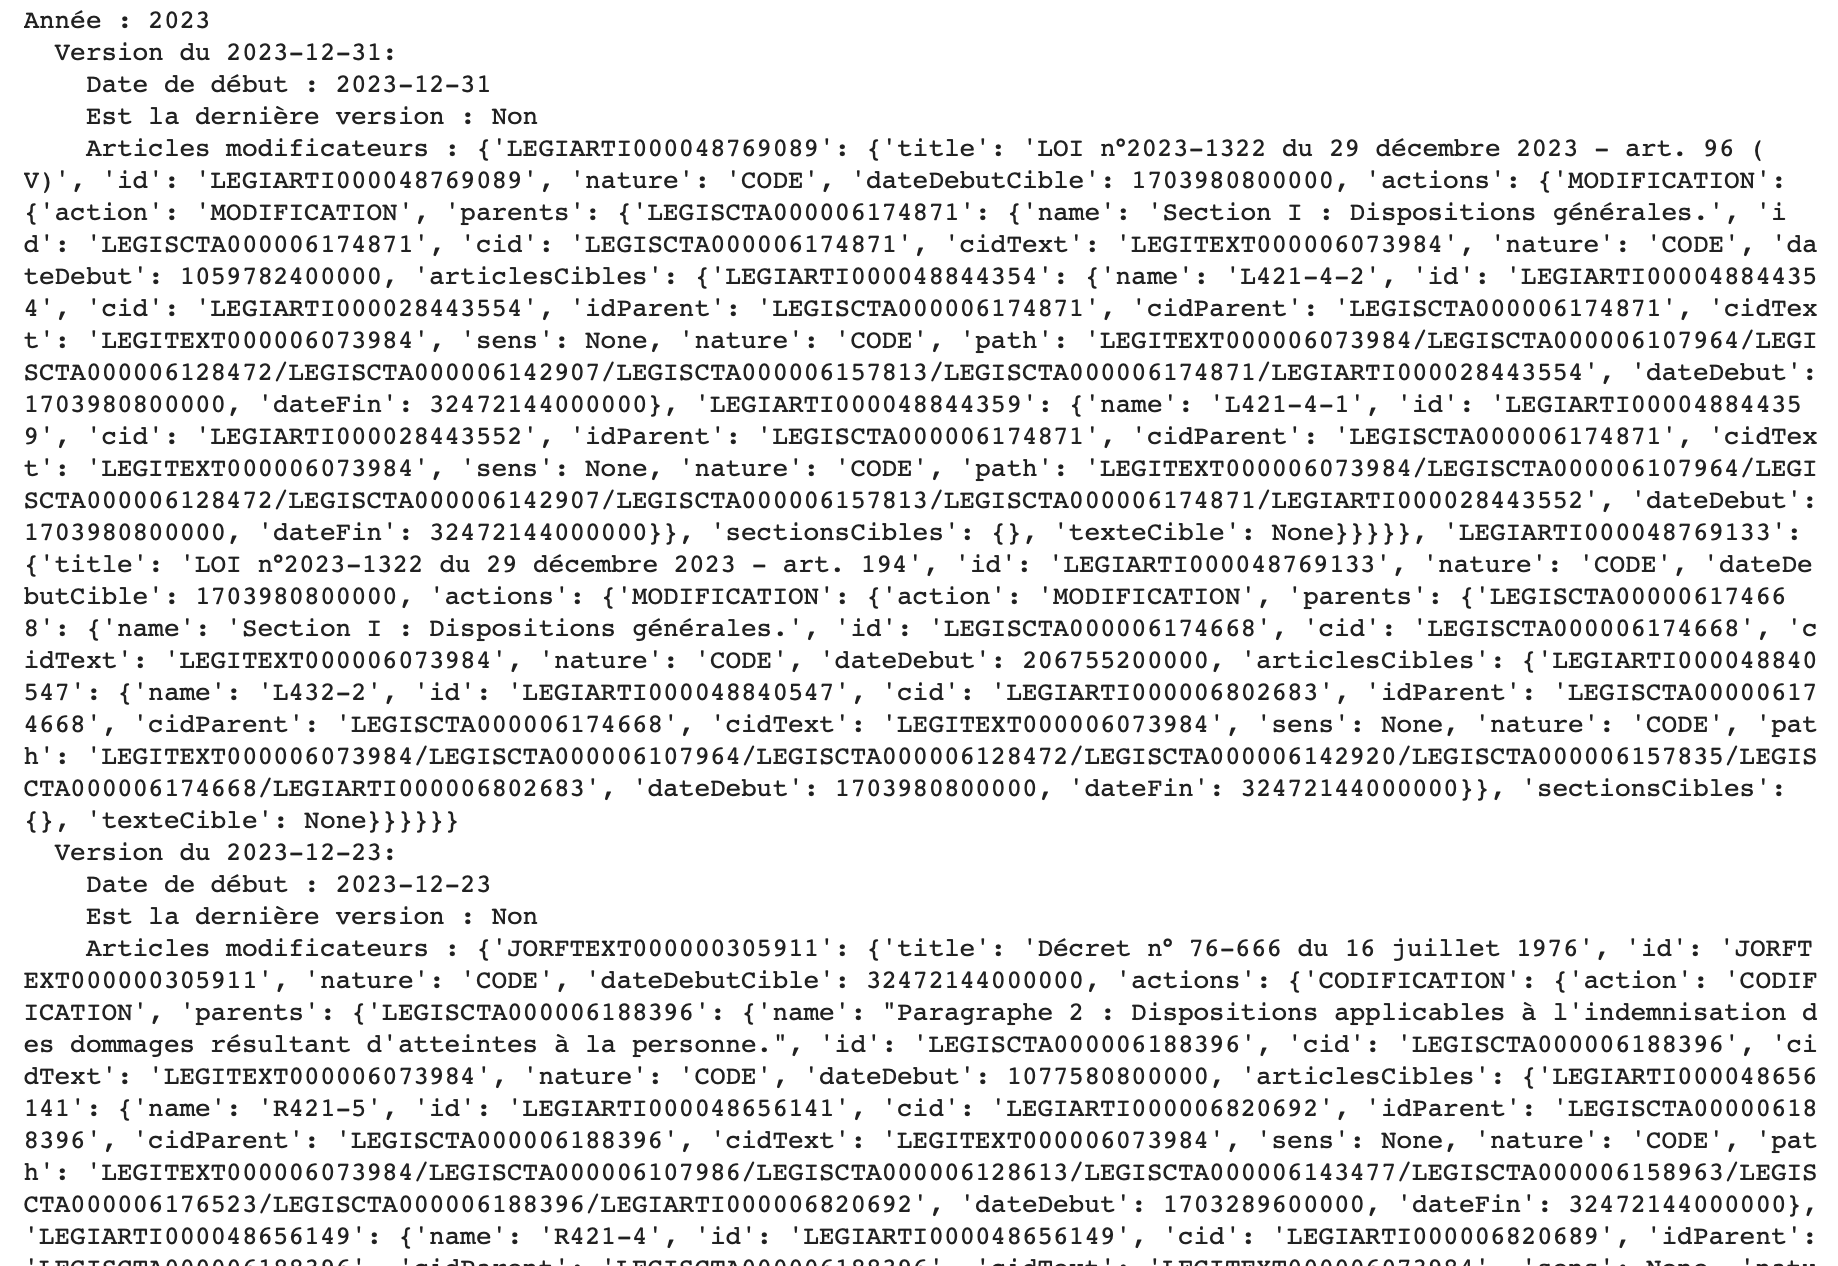

#### 2.2.3.4 Version 2 : data prep

In [ ]:
from datetime import datetime as dt

# Data cleaning
annee_recherchee = "2023"

# Vérifier la présence du champ 'regroupements' , 1 ou pluisieurs valo.
for group_1 in data_json_2_6_3['regroupements']:  # Parcours regroupement d'années : list de dictionnaires
    if group_1['title'] == annee_recherchee:  # Filtre pour l'année recherchée
        print(f"Année : {group_1['title']}")

        # Parcours de chaque version de texte pour l'année courante
        for version_date, version_data in group_1['versions'].items():
          # version_date: date de version du text
          # date_debut: date de début
            # Convertir le timestamp en une date lisible mil sec
            date_debut = dt.fromtimestamp(version_data['dateDebut'] / 1000).strftime('%Y-%m-%d')

            print(f"  Version du {version_date}:")
            print(f"    Date de début : {date_debut}")

            # Vérifie si dernière version
            if version_data['isEndVersion'] == True:
                print(f"    Est la dernière version : Oui")
            else:
                print(f"    Est la dernière version : Non")

            # Affiche des articles modificateurs
            print("    Articles modificateurs :")
            for article_id, article_data in version_data['articlesModificateurs'].items():
                print(f"      - ID : {article_id}")
                print(f"        Titre : {article_data['title']}")
                print(f"        Nature : {article_data['nature']}")
                date_debut_cible = dt.fromtimestamp(article_data['dateDebutCible'] / 1000).strftime('%Y-%m-%d')
                print(f"        Date de début cible : {date_debut_cible}")

# Code incomplet 'parent' valo manquant:
# 'parent' structure du texte dans laquelle se trouve cet article modificateur
# Valo anormales dates 2999 pour date de début cible pour:
# ID : LEGIARTI000046369156
# Titre : Ordonnance n°2022-1292 du 5 octobre 2022 - art. 10
# Tester

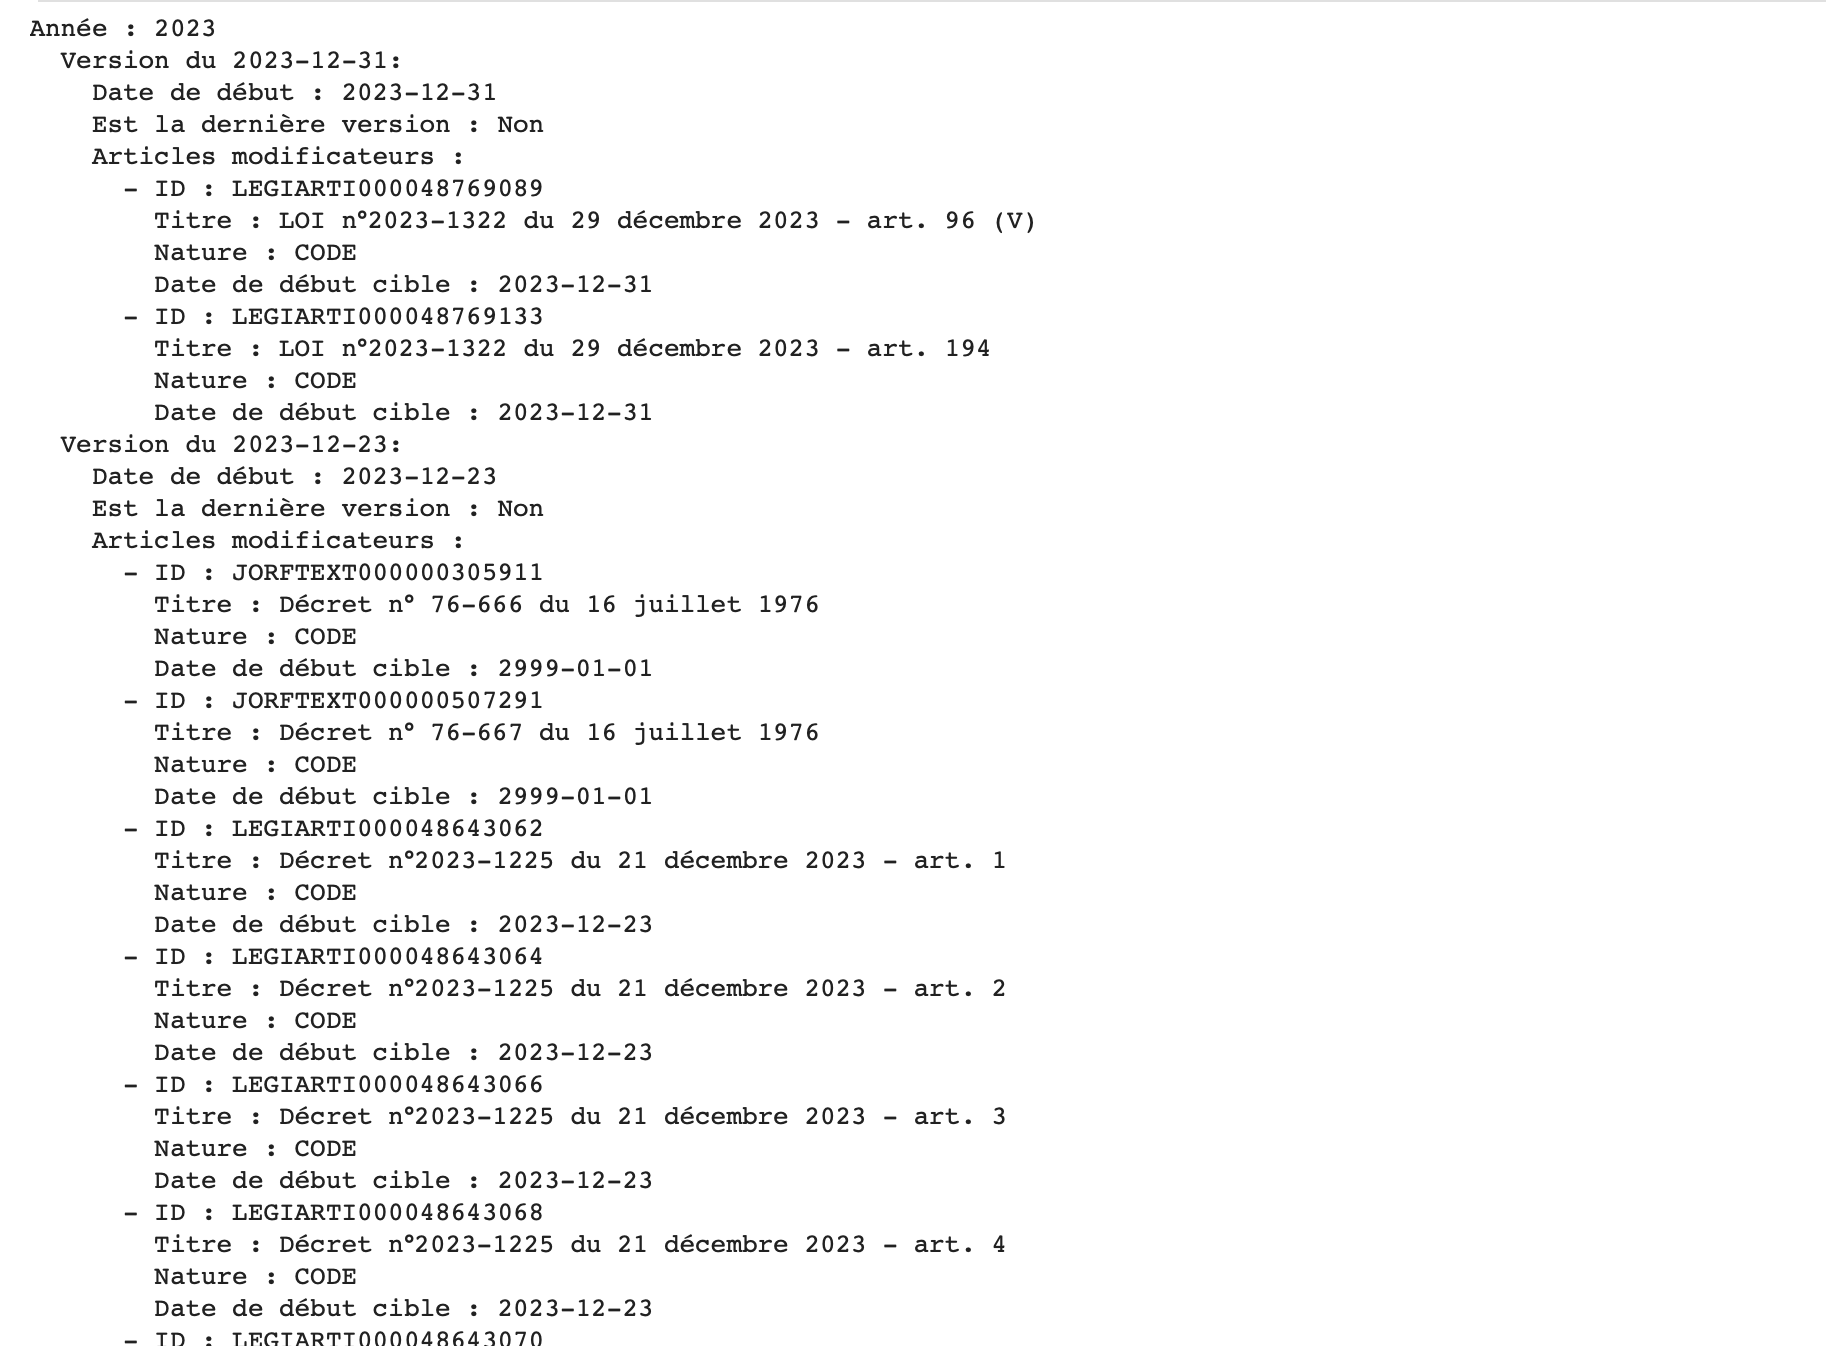

#### 2.2.3.5 Version 3 : data prep

Quid des articles cibles dans parent


In [ ]:
from datetime import datetime as dt

# Data cleaning
annee_recherchee = "2023"

# Vérifier la présence du champ 'regroupements' et l’analyser
for group_1 in data_json_2_6_3['regroupements']:  # Parcours regroupement d'années : list de dictionnaires
    if group_1['title'] == annee_recherchee:  # Filtre pour l'année recherchée
        print(f"Année : {group_1['title']}")

        # Parcours de chaque version de texte pour l'année courante
        for version_date, version_data in group_1['versions'].items():
            # Convertir le timestamp en une date lisible
            date_debut = dt.fromtimestamp(version_data['dateDebut'] / 1000).strftime('%Y-%m-%d')

            print(f"  Version du {version_date}:")
            print(f"    Date de début cible entrée en vigueur: {date_debut}")
            print(f"    Est la dernière version : {'Oui' if version_data['isEndVersion'] else 'Non'}")

            # Affichage des articles modificateurs
            print("    Articles modificateurs :")
            for article_id, article_data in version_data['articlesModificateurs'].items():
                print(f"      - ID : {article_id}")
                print(f"        Titre : {article_data['title']}")
                print(f"        Nature : {article_data['nature']}")
                date_debut_cible = dt.fromtimestamp(article_data['dateDebutCible'] / 1000).strftime('%Y-%m-%d')
                print(f"        Date de début cible : {date_debut_cible}")

                # Affichage des actions et des parents si disponibles
                if 'actions' in article_data:
                    for action_type, action_details in article_data['actions'].items():
                        print(f"        Action : {action_type}")

                        if 'parents' in action_details:
                            print("        Parents :")
                            for parent_id, parent_data in action_details['parents'].items():
                                print(f"          - ID parent  : {parent_id}")
                                print(f"            Nom parent : {parent_data['name']}")
                                print(f"            CID parent : {parent_data['cid']}")
                                if 'articlesCibles' in parent_data:
                                    print("            Articles cibles :")
                                    for cible_id, cible_data in parent_data['articlesCibles'].items():
                                        print(f"              - ID :{cible_id} - Article N° {cible_data['name']}")
                                        print(f"                    Date de début : {dt.fromtimestamp(cible_data['dateDebut'] / 1000).strftime('%Y-%m-%d')}")
                                        print(f"                    Date de fin : {dt.fromtimestamp(cible_data['dateFin'] / 1000).strftime('%Y-%m-%d')}")


Année : 2023
  Version du 2023-12-31:
    Date de début cible entrée en vigueur: 2023-12-31
    Est la dernière version : Non
    Articles modificateurs :
      - ID : LEGIARTI000048769089
        Titre : LOI n°2023-1322 du 29 décembre 2023 - art. 96 (V)
        Nature : CODE
        Date de début cible : 2023-12-31
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174871
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174871
            Articles cibles :
              - ID :LEGIARTI000048844354 - Article N° L421-4-2
                    Date de début : 2023-12-31
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048844359 - Article N° L421-4-1
                    Date de début : 2023-12-31
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048769133
        Titre : LOI n°2023-1322 du 29 décembre 2023 - art. 194
        Nature : CODE
        Date de début 

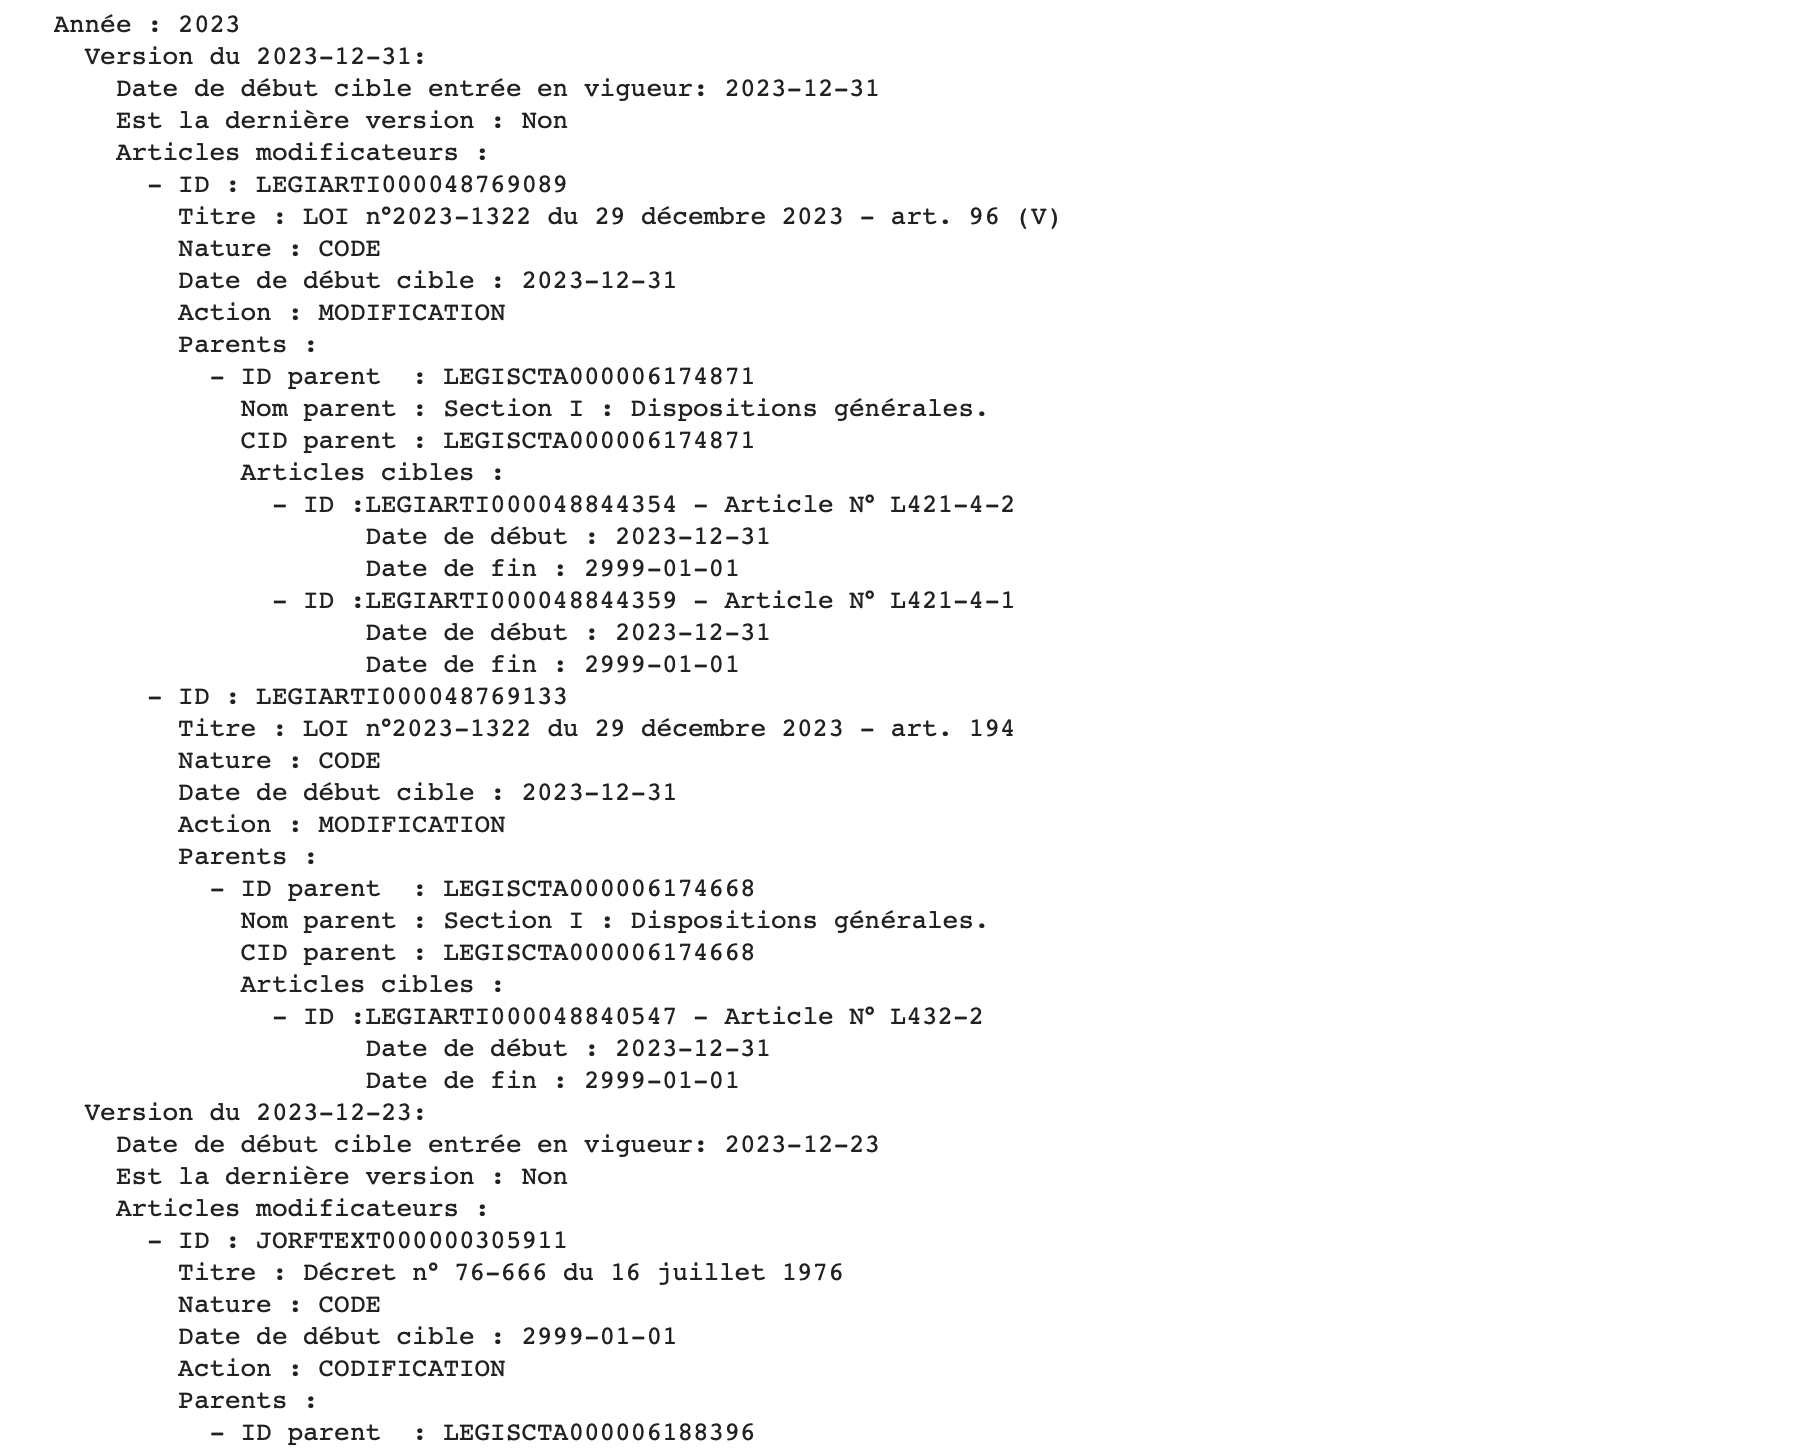

#### 2.2.3.5 Version 4 : data prep (stockage var) To do !!!!!

In [ ]:
resultats = """Année : 2023
  Version du 2023-12-31:
    Date de début cible entrée en vigueur: 2023-12-31
    Est la dernière version : Non
    Articles modificateurs :
      - ID : LEGIARTI000048769089
        Titre : LOI n°2023-1322 du 29 décembre 2023 - art. 96 (V)
        Nature : CODE
        Date de début cible : 2023-12-31
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174871
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174871
            Articles cibles :
              - ID :LEGIARTI000048844354 - Article N° L421-4-2
                    Date de début : 2023-12-31
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048844359 - Article N° L421-4-1
                    Date de début : 2023-12-31
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048769133
        Titre : LOI n°2023-1322 du 29 décembre 2023 - art. 194
        Nature : CODE
        Date de début cible : 2023-12-31
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174668
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174668
            Articles cibles :
              - ID :LEGIARTI000048840547 - Article N° L432-2
                    Date de début : 2023-12-31
                    Date de fin : 2999-01-01
  Version du 2023-12-23:
    Date de début cible entrée en vigueur: 2023-12-23
    Est la dernière version : Non
    Articles modificateurs :
      - ID : JORFTEXT000000305911
        Titre : Décret n° 76-666 du 16 juillet 1976
        Nature : CODE
        Date de début cible : 2999-01-01
        Action : CODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006188396
            Nom parent : Paragraphe 2 : Dispositions applicables à l'indemnisation des dommages résultant d'atteintes à la personne.
            CID parent : LEGISCTA000006188396
            Articles cibles :
              - ID :LEGIARTI000048656141 - Article N° R421-5
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048656149 - Article N° R421-4
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000006188416
            Nom parent : Paragraphe 3 : Dispositions applicables à l'indemnisation des dommages aux biens.
            CID parent : LEGISCTA000006188416
            Articles cibles :
              - ID :LEGIARTI000048656129 - Article N° R421-18
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000006188635
            Nom parent : Paragraphe 1 : Dispositions communes à l'indemnisation des dommages résultant d'atteintes à la personne et des dommages aux biens.
            CID parent : LEGISCTA000006188635
            Articles cibles :
              - ID :LEGIARTI000048656157 - Article N° R421-1
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000037205734
            Nom parent : Paragraphe 2 :  Relations entre le liquidateur et le fonds de garantie
            CID parent : LEGISCTA000037205734
            Articles cibles :
              - ID :LEGIARTI000048656183 - Article N° R421-54
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
      - ID : JORFTEXT000000507291
        Titre : Décret n° 76-667 du 16 juillet 1976
        Nature : CODE
        Date de début cible : 2999-01-01
        Action : CODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006175427
            Nom parent : Section III : Franchises, exclusions de garanties, déchéances et recours de l'assureur.
            CID parent : LEGISCTA000006175427
            Articles cibles :
              - ID :LEGIARTI000048656110 - Article N° R211-13
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000006175444
            Nom parent : Section V : Dispositions relatives à l'assurance des véhicules en circulation internationale et de certains autres véhicules.
            CID parent : LEGISCTA000006175444
            Articles cibles :
              - ID :LEGIARTI000048656121 - Article N° R*211-22
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048643062
        Titre : Décret n°2023-1225 du 21 décembre 2023 - art. 1
        Nature : CODE
        Date de début cible : 2023-12-23
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006175427
            Nom parent : Section III : Franchises, exclusions de garanties, déchéances et recours de l'assureur.
            CID parent : LEGISCTA000006175427
            Articles cibles :
              - ID :LEGIARTI000048656110 - Article N° R211-13
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048643064
        Titre : Décret n°2023-1225 du 21 décembre 2023 - art. 2
        Nature : CODE
        Date de début cible : 2023-12-23
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006175444
            Nom parent : Section V : Dispositions relatives à l'assurance des véhicules en circulation internationale et de certains autres véhicules.
            CID parent : LEGISCTA000006175444
            Articles cibles :
              - ID :LEGIARTI000048656121 - Article N° R*211-22
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048643066
        Titre : Décret n°2023-1225 du 21 décembre 2023 - art. 3
        Nature : CODE
        Date de début cible : 2023-12-23
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006188396
            Nom parent : Paragraphe 2 : Dispositions applicables à l'indemnisation des dommages résultant d'atteintes à la personne.
            CID parent : LEGISCTA000006188396
            Articles cibles :
              - ID :LEGIARTI000048656141 - Article N° R421-5
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048656149 - Article N° R421-4
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000006188416
            Nom parent : Paragraphe 3 : Dispositions applicables à l'indemnisation des dommages aux biens.
            CID parent : LEGISCTA000006188416
            Articles cibles :
              - ID :LEGIARTI000048656129 - Article N° R421-18
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000006188635
            Nom parent : Paragraphe 1 : Dispositions communes à l'indemnisation des dommages résultant d'atteintes à la personne et des dommages aux biens.
            CID parent : LEGISCTA000006188635
            Articles cibles :
              - ID :LEGIARTI000048656157 - Article N° R421-1
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048643068
        Titre : Décret n°2023-1225 du 21 décembre 2023 - art. 4
        Nature : CODE
        Date de début cible : 2023-12-23
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000037205726
            Nom parent : Paragraphe 1 : Intervention du fonds de garantie
            CID parent : LEGISCTA000037205726
            Articles cibles :
              - ID :LEGIARTI000048656191 - Article N° R421-50
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000037205734
            Nom parent : Paragraphe 2 :  Relations entre le liquidateur et le fonds de garantie
            CID parent : LEGISCTA000037205734
            Articles cibles :
              - ID :LEGIARTI000048656171 - Article N° R421-55
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048656183 - Article N° R421-54
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048643070
        Titre : Décret n°2023-1225 du 21 décembre 2023 - art. 5
        Nature : CODE
        Date de début cible : 2023-12-23
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006143494
            Nom parent : Titre V : Organisme d'information
            CID parent : LEGISCTA000006143494
            Articles cibles :
              - ID :LEGIARTI000048656204 - Article N° R451-6
                    Date de début : 2023-12-23
                    Date de fin : 2999-01-01
  Version du 2023-12-08:
    Date de début cible entrée en vigueur: 2023-12-08
    Est la dernière version : Non
    Articles modificateurs :
      - ID : JORFTEXT000000305911
        Titre : Décret n° 76-666 du 16 juillet 1976
        Nature : CODE
        Date de début cible : 2999-01-01
        Action : CODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174271
            Nom parent : Section VII : Pénalités.
            CID parent : LEGISCTA000006174271
            Articles cibles :
              - ID :LEGIARTI000048523661 - Article N° L211-27
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000006174871
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174871
            Articles cibles :
              - ID :LEGIARTI000048523673 - Article N° L421-7
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523687 - Article N° L421-3
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000006174893
            Nom parent : Section IX : Dispositions particulières applicables aux accidents d'automobile survenus à l'étranger.
            CID parent : LEGISCTA000006174893
            Articles cibles :
              - ID :LEGIARTI000048523758 - Article N° L421-15
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523764 - Article N° L421-12
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523773 - Article N° L421-11
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000036103236
            Nom parent : Section VI : Intervention du fonds en cas de retrait d'agrément administratif d'une entreprise d'assurance
            CID parent : LEGISCTA000006174617
            Articles cibles :
              - ID :LEGIARTI000048523704 - Article N° L421-9
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523751 - Article N° L421-10
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
      - ID : JORFTEXT000000684682
        Titre : Décret n°88-260 du 18 mars 1988
        Nature : CODE
        Date de début cible : 2999-01-01
        Action : CODIFICATION
        Parents :
          - ID parent  : LEGISCTA000048521277
            Nom parent : Section 1 : Intervention de l'organisme d'indemnisation en l'absence de réponse ou de représentant de l'entreprise d'assurance
            CID parent : LEGISCTA000048521277
            Articles cibles :
              - ID :LEGIARTI000048523781 - Article N° L424-1
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523791 - Article N° L424-7
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523798 - Article N° L424-6
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523805 - Article N° L424-5
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523812 - Article N° L424-4
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523817 - Article N° L424-3
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523822 - Article N° L424-2
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048520144
        Titre : Ordonnance n°2023-1138 du 6 décembre 2023 - art. 2
        Nature : CODE
        Date de début cible : 2023-12-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174242
            Nom parent : Section I : Personnes assujetties.
            CID parent : LEGISCTA000006174242
            Articles cibles :
              - ID :LEGIARTI000048523650 - Article N° L211-1
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048520146
        Titre : Ordonnance n°2023-1138 du 6 décembre 2023 - art. 3
        Nature : CODE
        Date de début cible : 2023-12-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174247
            Nom parent : Section II : Etendue de l'obligation d'assurance.
            CID parent : LEGISCTA000006174247
            Articles cibles :
              - ID :LEGIARTI000048523653 - Article N° L211-4-1
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523656 - Article N° L211-4
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048520148
        Titre : Ordonnance n°2023-1138 du 6 décembre 2023 - art. 4
        Nature : CODE
        Date de début cible : 2023-12-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174271
            Nom parent : Section VII : Pénalités.
            CID parent : LEGISCTA000006174271
            Articles cibles :
              - ID :LEGIARTI000048523661 - Article N° L211-27
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048520150
        Titre : Ordonnance n°2023-1138 du 6 décembre 2023 - art. 5
        Nature : CODE
        Date de début cible : 2023-12-08
        Action : CREATION
        Parents :
          - ID parent  : LEGISCTA000006157480
            Nom parent : Chapitre Ier : L'obligation de s'assurer
            CID parent : LEGISCTA000006157480
            Articles cibles :
          - ID parent  : LEGISCTA000048520400
            Nom parent : Section VIII : Transparence et comparaison des offres
            CID parent : LEGISCTA000048520400
            Articles cibles :
              - ID :LEGIARTI000048520425 - Article N° L211-28
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048520152
        Titre : Ordonnance n°2023-1138 du 6 décembre 2023 - art. 6
        Nature : CODE
        Date de début cible : 2023-12-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006128472
            Nom parent : Livre IV : Organisations et régimes particuliers d'assurance
            CID parent : LEGISCTA000006128472
            Articles cibles :
      - ID : LEGIARTI000048520154
        Titre : Ordonnance n°2023-1138 du 6 décembre 2023 - art. 7
        Nature : CODE
        Date de début cible : 2023-12-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174871
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174871
            Articles cibles :
              - ID :LEGIARTI000048523673 - Article N° L421-7
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523687 - Article N° L421-3
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523697 - Article N° L421-1
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048520156
        Titre : Ordonnance n°2023-1138 du 6 décembre 2023 - art. 8
        Nature : CODE
        Date de début cible : 2023-12-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000036103236
            Nom parent : Section VI : Intervention du fonds en cas de retrait d'agrément administratif d'une entreprise d'assurance
            CID parent : LEGISCTA000006174617
            Articles cibles :
              - ID :LEGIARTI000048523704 - Article N° L421-9
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048520158
        Titre : Ordonnance n°2023-1138 du 6 décembre 2023 - art. 9
        Nature : CODE
        Date de début cible : 2023-12-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000036103236
            Nom parent : Section VI : Intervention du fonds en cas de retrait d'agrément administratif d'une entreprise d'assurance
            CID parent : LEGISCTA000006174617
            Articles cibles :
              - ID :LEGIARTI000048523735 - Article N° L421-9-1
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048520160
        Titre : Ordonnance n°2023-1138 du 6 décembre 2023 - art. 10
        Nature : CODE
        Date de début cible : 2023-12-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000036103236
            Nom parent : Section VI : Intervention du fonds en cas de retrait d'agrément administratif d'une entreprise d'assurance
            CID parent : LEGISCTA000006174617
            Articles cibles :
              - ID :LEGIARTI000048523742 - Article N° L421-9-4
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048520162
        Titre : Ordonnance n°2023-1138 du 6 décembre 2023 - art. 11
        Nature : CODE
        Date de début cible : 2023-12-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000036103236
            Nom parent : Section VI : Intervention du fonds en cas de retrait d'agrément administratif d'une entreprise d'assurance
            CID parent : LEGISCTA000006174617
            Articles cibles :
              - ID :LEGIARTI000048523751 - Article N° L421-10
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048520164
        Titre : Ordonnance n°2023-1138 du 6 décembre 2023 - art. 12
        Nature : CODE
        Date de début cible : 2023-12-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174893
            Nom parent : Section IX : Dispositions particulières applicables aux accidents d'automobile survenus à l'étranger.
            CID parent : LEGISCTA000006174893
            Articles cibles :
              - ID :LEGIARTI000048523758 - Article N° L421-15
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523764 - Article N° L421-12
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523773 - Article N° L421-11
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048520166
        Titre : Ordonnance n°2023-1138 du 6 décembre 2023 - art. 13
        Nature : CODE
        Date de début cible : 2023-12-08
        Action : CREATION
        Parents :
          - ID parent  : LEGISCTA000006157821
            Nom parent : Chapitre IV : Organisme d'indemnisation
            CID parent : LEGISCTA000006157821
            Articles cibles :
          - ID parent  : LEGISCTA000048521279
            Nom parent : Section 2 :  Intervention de l'organisme d'indemnisation en cas d'insolvabilité d'une entreprise d'assurance dont le siège est situé dans un Etat de l'Espace économique européen autre que la France
            CID parent : LEGISCTA000048521279
            Articles cibles :
              - ID :LEGIARTI000048521334 - Article N° L424-8
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048521339 - Article N° L424-9
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048521341 - Article N° L424-10
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048521345 - Article N° L424-11
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
        Action : DEPLACEMENT
        Parents :
          - ID parent  : LEGISCTA000048521277
            Nom parent : Section 1 : Intervention de l'organisme d'indemnisation en l'absence de réponse ou de représentant de l'entreprise d'assurance
            CID parent : LEGISCTA000048521277
            Articles cibles :
              - ID :LEGIARTI000048523791 - Article N° L424-7
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523798 - Article N° L424-6
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523805 - Article N° L424-5
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523812 - Article N° L424-4
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523817 - Article N° L424-3
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000048523822 - Article N° L424-2
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000048521277
            Nom parent : Section 1 : Intervention de l'organisme d'indemnisation en l'absence de réponse ou de représentant de l'entreprise d'assurance
            CID parent : LEGISCTA000048521277
            Articles cibles :
              - ID :LEGIARTI000048523781 - Article N° L424-1
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048520168
        Titre : Ordonnance n°2023-1138 du 6 décembre 2023 - art. 14
        Nature : CODE
        Date de début cible : 2023-12-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006142925
            Nom parent : Titre V : Organisme d'information
            CID parent : LEGISCTA000006142925
            Articles cibles :
              - ID :LEGIARTI000048523830 - Article N° L451-2
                    Date de début : 2023-12-08
                    Date de fin : 2999-01-01
  Version du 2023-11-01:
    Date de début cible entrée en vigueur: 2023-11-01
    Est la dernière version : Non
    Articles modificateurs :
      - ID : LEGIARTI000046853982
        Titre : Décret n°2022-1737 du 30 décembre 2022 - art. 1
        Nature : CODE
        Date de début cible : 2023-01-01
        Action : CREATION
        Parents :
          - ID parent  : LEGISCTA000046890144
            Nom parent : Section 3 :  Les conditions de prise en charge des frais de relogement d'urgence
            CID parent : LEGISCTA000046890144
            Articles cibles :
              - ID :LEGIARTI000046891261 - Article N° D125-4
                    Date de début : 2023-11-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046891270 - Article N° D125-4-1
                    Date de début : 2023-11-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046891278 - Article N° D125-4-2
                    Date de début : 2023-11-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046891282 - Article N° D125-4-3
                    Date de début : 2023-11-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046891292 - Article N° D125-4-4
                    Date de début : 2023-11-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000046882315
        Titre : Arrêté du 30 décembre 2022 - art. 1
        Nature : CODE
        Date de début cible : 2023-01-01
        Action : CREATION
        Parents :
          - ID parent  : LEGISCTA000006156960
            Nom parent : Chapitre V : L'assurance des risques de catastrophes naturelles.
            CID parent : LEGISCTA000006156960
            Articles cibles :
          - ID parent  : LEGISCTA000046884224
            Nom parent : Section 2 : La prise en charge des frais de relogement d'urgence
            CID parent : LEGISCTA000046884148
            Articles cibles :
              - ID :LEGIARTI000046884294 - Article N° A125-5-1
                    Date de début : 2023-11-01
                    Date de fin : 2999-01-01
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000046884224
            Nom parent : Section 2 : La prise en charge des frais de relogement d'urgence
            CID parent : LEGISCTA000046884148
            Articles cibles :
              - ID :LEGIARTI000046918899 - Article N° A125-5
                    Date de début : 2023-11-01
                    Date de fin : 2999-01-01
  Version du 2023-10-25:
    Date de début cible entrée en vigueur: 2023-10-25
    Est la dernière version : Non
    Articles modificateurs :
      - ID : LEGIARTI000048243192
        Titre : LOI n°2023-973 du 23 octobre 2023 - art. 31
        Nature : CODE
        Date de début cible : 2023-10-25
        Action : CREATION
        Parents :
          - ID parent  : LEGISCTA000006174668
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174668
            Articles cibles :
              - ID :LEGIARTI000048243369 - Article N° L432-5-1
                    Date de début : 2023-10-25
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000048243194
        Titre : LOI n°2023-973 du 23 octobre 2023 - art. 36
        Nature : CODE
        Date de début cible : 2023-10-25
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174083
            Nom parent : Section II : Plan d'épargne retraite populaire
            CID parent : LEGISCTA000006174083
            Articles cibles :
              - ID :LEGIARTI000048252395 - Article N° L144-2
                    Date de début : 2023-10-25
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000038836986
            Nom parent : Chapitre II : Plans d'épargne retraite donnant lieu à l'adhésion à un contrat d'assurance de groupe
            CID parent : LEGISCTA000006157902
            Articles cibles :
              - ID :LEGIARTI000048252409 - Article N° L142-7
                    Date de début : 2023-10-25
                    Date de fin : 2999-01-01
  Version du 2023-07-22:
    Date de début cible entrée en vigueur: 2023-07-22
    Est la dernière version : Non
    Articles modificateurs :
      - ID : LEGIARTI000047868556
        Titre : Arrêté du 17 juillet 2023 - art. 1
        Nature : CODE
        Date de début cible : 2023-07-22
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006173957
            Nom parent : Section IV : Rachat par les entreprises d'assurance sur la vie des rentes inférieures à un certain montant minimal.
            CID parent : LEGISCTA000006173957
            Articles cibles :
              - ID :LEGIARTI000047871712 - Article N° A160-2
                    Date de début : 2023-07-22
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047868560
        Titre : Arrêté du 17 juillet 2023 - art. 2
        Nature : CODE
        Date de début cible : 2023-07-22
        Action : ABROGATION
        Parents :
          - ID parent  : LEGISCTA000006173957
            Nom parent : Section IV : Rachat par les entreprises d'assurance sur la vie des rentes inférieures à un certain montant minimal.
            CID parent : LEGISCTA000006173957
            Articles cibles :
              - ID :LEGIARTI000043743285 - Article N° A160-2-1
                    Date de début : 2021-07-01
                    Date de fin : 2023-07-22
  Version du 2023-07-01:
    Date de début cible entrée en vigueur: 2023-07-01
    Est la dernière version : Non
    Articles modificateurs :
      - ID : LEGIARTI000047429053
        Titre : Arrêté du 4 avril 2023 - art. 1
        Nature : CODE
        Date de début cible : 2023-07-01
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000039798600
            Nom parent : Chapitre Ier : Exigences en ce qui concerne les contrats de capitalisation et certains contrats d'assurance vie
            CID parent : LEGISCTA000039798587
            Articles cibles :
              - ID :LEGIARTI000047429467 - Article N° A522-1
                    Date de début : 2023-07-01
                    Date de fin : 2025-01-01
      - ID : LEGIARTI000047429059
        Titre : Arrêté du 4 avril 2023 - art.
        Nature : CODE
        Date de début cible : 2023-07-01
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000039798600
            Nom parent : Chapitre Ier : Exigences en ce qui concerne les contrats de capitalisation et certains contrats d'assurance vie
            CID parent : LEGISCTA000039798587
            Articles cibles :
              - ID :LEGIARTI000047429476 - Article N° Annexe art. A522-1
                    Date de début : 2023-07-01
                    Date de fin : 2999-01-01
  Version du 2023-06-18:
    Date de début cible entrée en vigueur: 2023-06-18
    Est la dernière version : Non
    Articles modificateurs :
      - ID : JORFTEXT000000507291
        Titre : Décret n° 76-667 du 16 juillet 1976
        Nature : CODE
        Date de début cible : 2999-01-01
        Action : CODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006158211
            Nom parent : Chapitre Ier : Dispositions générales.
            CID parent : LEGISCTA000006158211
            Articles cibles :
              - ID :LEGIARTI000047696965 - Article N° R111-1
                    Date de début : 2023-06-18
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047694960
        Titre : Décret n°2023-466 du 14 juin 2023 - art. 1
        Nature : CODE
        Date de début cible : 2023-06-18
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006158211
            Nom parent : Chapitre Ier : Dispositions générales.
            CID parent : LEGISCTA000006158211
            Articles cibles :
              - ID :LEGIARTI000047696965 - Article N° R111-1
                    Date de début : 2023-06-18
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047695419
        Titre : Arrêté du 14 juin 2023 - art. 1
        Nature : CODE
        Date de début cible : 2023-06-18
        Action : CREATION
        Parents :
          - ID parent  : LEGISCTA000017726060
            Nom parent : Chapitre Ier : Dispositions générales.
            CID parent : LEGISCTA000017726033
            Articles cibles :
              - ID :LEGIARTI000047695515 - Article N° A111-7
                    Date de début : 2023-06-18
                    Date de fin : 2999-01-01
  Version du 2023-06-10:
    Date de début cible entrée en vigueur: 2023-06-10
    Est la dernière version : Non
    Articles modificateurs :
      - ID : LEGIARTI000047657911
        Titre : Décret n°2023-449 du 7 juin 2023 - art. 1
        Nature : CODE
        Date de début cible : 2023-06-10
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000030584408
            Nom parent : Sous-section 4 : Provisions techniques des opérations de réassurance

            CID parent : LEGISCTA000030576283
            Articles cibles :
              - ID :LEGIARTI000047658106 - Article N° R343-8
                    Date de début : 2023-06-10
                    Date de fin : 2024-06-10
          - ID parent  : LEGISCTA000030584411
            Nom parent : Sous-section 3 : Provisions techniques des autres opérations d'assurance

            CID parent : LEGISCTA000030576279
            Articles cibles :
              - ID :LEGIARTI000047658116 - Article N° R343-7
                    Date de début : 2023-06-10
                    Date de fin : 2024-06-10
  Version du 2023-06-01:
    Date de début cible entrée en vigueur: 2023-06-01
    Est la dernière version : Non
    Articles modificateurs :
      - ID : JORFTEXT000000305911
        Titre : Décret n° 76-666 du 16 juillet 1976
        Nature : CODE
        Date de début cible : 2999-01-01
        Action : CODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006157200
            Nom parent : Chapitre III : Obligations de l'assureur et de l'assuré.
            CID parent : LEGISCTA000006157200
            Articles cibles :
              - ID :LEGIARTI000046194186 - Article N° L113-14
                    Date de début : 2023-06-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000046188489
        Titre : LOI n°2022-1158 du 16 août 2022 - art. 17 (V)
        Nature : CODE
        Date de début cible : 2022-08-18
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006157200
            Nom parent : Chapitre III : Obligations de l'assureur et de l'assuré.
            CID parent : LEGISCTA000006157200
            Articles cibles :
              - ID :LEGIARTI000046194186 - Article N° L113-14
                    Date de début : 2023-06-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000046722591
        Titre : Arrêté du 6 décembre 2022 - art. 1
        Nature : CODE
        Date de début cible : 2022-12-11
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006173948
            Nom parent : Section I : Obligation d'immatriculation.
            CID parent : LEGISCTA000006173948
            Articles cibles :
              - ID :LEGIARTI000046723658 - Article N° A512-1
                    Date de début : 2023-06-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000046722593
        Titre : Arrêté du 6 décembre 2022 - art. 2
        Nature : CODE
        Date de début cible : 2022-12-11
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006173948
            Nom parent : Section I : Obligation d'immatriculation.
            CID parent : LEGISCTA000006173948
            Articles cibles :
              - ID :LEGIARTI000046723670 - Article N° A512-3
                    Date de début : 2023-06-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047314925
        Titre : Décret n°2023-182 du 16 mars 2023 - art. 1
        Nature : CODE
        Date de début cible : 2023-06-01
        Action : CREATION
        Parents :
          - ID parent  : LEGISCTA000006158221
            Nom parent : Chapitre III : Obligations de l'assureur et de l'assuré.
            CID parent : LEGISCTA000006158221
            Articles cibles :
              - ID :LEGIARTI000047314962 - Article N° D113-7
                    Date de début : 2023-06-01
                    Date de fin : 2999-01-01
  Version du 2023-05-26:
    Date de début cible entrée en vigueur: 2023-05-26
    Est la dernière version : Non
    Articles modificateurs :
      - ID : JORFTEXT000000305911
        Titre : Décret n° 76-666 du 16 juillet 1976
        Nature : CODE
        Date de début cible : 2999-01-01
        Action : CODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174434
            Nom parent : Section I : Règles générales.
            CID parent : LEGISCTA000006174434
            Articles cibles :
              - ID :LEGIARTI000047591418 - Article N° L324-2
                    Date de début : 2023-05-26
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047585352
        Titre : Ordonnance n°2023-393 du 24 mai 2023 - art. 12 (V)
        Nature : CODE
        Date de début cible : 2023-05-26
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174434
            Nom parent : Section I : Règles générales.
            CID parent : LEGISCTA000006174434
            Articles cibles :
              - ID :LEGIARTI000047591418 - Article N° L324-2
                    Date de début : 2023-05-26
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000017868431
            Nom parent : Titre IX : Dispositions applicables dans les îles Wallis et Futuna
            CID parent : LEGISCTA000017851924
            Articles cibles :
              - ID :LEGIARTI000047591401 - Article N° L390-1
                    Date de début : 2023-05-26
                    Date de fin : 2024-01-01
  Version du 2023-04-24:
    Date de début cible entrée en vigueur: 2023-04-24
    Est la dernière version : Non
    Articles modificateurs :
      - ID : LEGIARTI000047047843
        Titre : LOI n°2023-22 du 24 janvier 2023 - art. 5 (V)
        Nature : CODE
        Date de début cible : 2023-01-26
        Action : CREATION
        Parents :
          - ID parent  : LEGISCTA000024376800
            Nom parent : Titre II : Règles relatives aux assurances de dommages
            CID parent : LEGISCTA000006142679
            Articles cibles :
          - ID parent  : LEGISCTA000047048148
            Nom parent : Chapitre X : L'assurance des risques de cyberattaques
            CID parent : LEGISCTA000047048143
            Articles cibles :
              - ID :LEGIARTI000047048152 - Article N° L12-10-1
                    Date de début : 2023-04-24
                    Date de fin : 2999-01-01
  Version du 2023-04-20:
    Date de début cible entrée en vigueur: 2023-04-20
    Est la dernière version : Non
    Articles modificateurs :
      - ID : LEGIARTI000047462836
        Titre : Arrêté du 17 avril 2023 - art. 1
        Nature : CODE
        Date de début cible : 2023-04-20
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000021005061
            Nom parent : Section I : Dispositions générales
            CID parent : LEGISCTA000021005061
            Articles cibles :
              - ID :LEGIARTI000047463490 - Article N° A310-2
                    Date de début : 2023-04-20
                    Date de fin : 2999-01-01
  Version du 2023-04-08:
    Date de début cible entrée en vigueur: 2023-04-08
    Est la dernière version : Non
    Articles modificateurs :
      - ID : JORFTEXT000000305911
        Titre : Décret n° 76-666 du 16 juillet 1976
        Nature : CODE
        Date de début cible : 2999-01-01
        Action : CODIFICATION
        Parents :
          - ID parent  : LEGISCTA000033603937
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006188306
            Articles cibles :
              - ID :LEGIARTI000047418812 - Article N° R442-2
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000047418831 - Article N° R442-7-2
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000037832436
            Nom parent : Section II : Opérations d'exportation
            CID parent : LEGISCTA000006188307
            Articles cibles :
              - ID :LEGIARTI000047418854 - Article N° R442-8-4
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047417202
        Titre : Décret n°2023-254 du 5 avril 2023 - art. 4
        Nature : CODE
        Date de début cible : 2023-04-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000037832436
            Nom parent : Section II : Opérations d'exportation
            CID parent : LEGISCTA000006188307
            Articles cibles :
              - ID :LEGIARTI000047418840 - Article N° R442-8-2
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047417204
        Titre : Décret n°2023-254 du 5 avril 2023 - art. 5
        Nature : CODE
        Date de début cible : 2023-04-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000033603720
            Nom parent : Section V : Opérations d'achat par des entreprises françaises auprès de fournisseurs français en concurrence avec une entreprise étrangère bénéficiant d'un soutien public à l'exportation
            CID parent : LEGISCTA000033142852
            Articles cibles :
              - ID :LEGIARTI000047418849 - Article N° R442-10-7
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000037832436
            Nom parent : Section II : Opérations d'exportation
            CID parent : LEGISCTA000006188307
            Articles cibles :
              - ID :LEGIARTI000047418840 - Article N° R442-8-2
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000045092658
            Nom parent : Section VI : Opérations présentant un intérêt stratégique pour l'économie française à l'étranger
            CID parent : LEGISCTA000037830443
            Articles cibles :
              - ID :LEGIARTI000047418845 - Article N° R442-11-2
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047417206
        Titre : Décret n°2023-254 du 5 avril 2023 - art. 6
        Nature : CODE
        Date de début cible : 2023-04-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000037832436
            Nom parent : Section II : Opérations d'exportation
            CID parent : LEGISCTA000006188307
            Articles cibles :
              - ID :LEGIARTI000047418854 - Article N° R442-8-4
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047417208
        Titre : Décret n°2023-254 du 5 avril 2023 - art. 7
        Nature : CODE
        Date de début cible : 2023-04-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000037832436
            Nom parent : Section II : Opérations d'exportation
            CID parent : LEGISCTA000006188307
            Articles cibles :
              - ID :LEGIARTI000047418860 - Article N° R442-8-8
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047417210
        Titre : Décret n°2023-254 du 5 avril 2023 - art. 9
        Nature : CODE
        Date de début cible : 2023-04-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000033603720
            Nom parent : Section V : Opérations d'achat par des entreprises françaises auprès de fournisseurs français en concurrence avec une entreprise étrangère bénéficiant d'un soutien public à l'exportation
            CID parent : LEGISCTA000033142852
            Articles cibles :
              - ID :LEGIARTI000047418849 - Article N° R442-10-7
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047417212
        Titre : Décret n°2023-254 du 5 avril 2023 - art. 11
        Nature : CODE
        Date de début cible : 2023-04-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000045092658
            Nom parent : Section VI : Opérations présentant un intérêt stratégique pour l'économie française à l'étranger
            CID parent : LEGISCTA000037830443
            Articles cibles :
              - ID :LEGIARTI000047418870 - Article N° R442-11-3
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047417218
        Titre : Décret n°2023-254 du 5 avril 2023 - art. 1
        Nature : CODE
        Date de début cible : 2023-04-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000033603937
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006188306
            Articles cibles :
              - ID :LEGIARTI000047418812 - Article N° R442-2
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047417220
        Titre : Décret n°2023-254 du 5 avril 2023 - art. 2
        Nature : CODE
        Date de début cible : 2023-04-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000033603937
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006188306
            Articles cibles :
              - ID :LEGIARTI000047418822 - Article N° R442-5
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047417222
        Titre : Décret n°2023-254 du 5 avril 2023 - art. 3
        Nature : CODE
        Date de début cible : 2023-04-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000033603937
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006188306
            Articles cibles :
              - ID :LEGIARTI000047418831 - Article N° R442-7-2
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047417224
        Titre : Décret n°2023-254 du 5 avril 2023 - art. 8
        Nature : CODE
        Date de début cible : 2023-04-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000037832436
            Nom parent : Section II : Opérations d'exportation
            CID parent : LEGISCTA000006188307
            Articles cibles :
              - ID :LEGIARTI000047418863 - Article N° R442-8-9
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047417226
        Titre : Décret n°2023-254 du 5 avril 2023 - art. 10
        Nature : CODE
        Date de début cible : 2023-04-08
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000045092658
            Nom parent : Section VI : Opérations présentant un intérêt stratégique pour l'économie française à l'étranger
            CID parent : LEGISCTA000037830443
            Articles cibles :
              - ID :LEGIARTI000047418845 - Article N° R442-11-2
                    Date de début : 2023-04-08
                    Date de fin : 2999-01-01
  Version du 2023-04-03:
    Date de début cible entrée en vigueur: 2023-04-03
    Est la dernière version : Non
    Articles modificateurs :
      - ID : LEGIARTI000047390007
        Titre : Décret n°2023-243 du 31 mars 2023 - art. 1
        Nature : CODE
        Date de début cible : 2023-04-03
        Action : CREATION
        Parents :
          - ID parent  : LEGISCTA000006143493
            Nom parent : Titre IV : Régimes particuliers d'assurance
            CID parent : LEGISCTA000006143493
            Articles cibles :
          - ID parent  : LEGISCTA000047390097
            Nom parent : Chapitre III : Régime d'indemnisation des risques en agriculture
            CID parent : LEGISCTA000047390097
            Articles cibles :
              - ID :LEGIARTI000047390099 - Article N° D443-1
                    Date de début : 2023-04-03
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000047390101 - Article N° D443-2
                    Date de début : 2023-04-03
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000047390103 - Article N° D443-3
                    Date de début : 2023-04-03
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000047390105 - Article N° D443-4
                    Date de début : 2023-04-03
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000047390107 - Article N° D443-5
                    Date de début : 2023-04-03
                    Date de fin : 2999-01-01
  Version du 2023-03-11:
    Date de début cible entrée en vigueur: 2023-03-11
    Est la dernière version : Non
    Articles modificateurs :
      - ID : JORFTEXT000000305911
        Titre : Décret n° 76-666 du 16 juillet 1976
        Nature : CODE
        Date de début cible : 2999-01-01
        Action : CODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006157198
            Nom parent : Chapitre Ier : Dispositions générales.
            CID parent : LEGISCTA000006157198
            Articles cibles :
              - ID :LEGIARTI000047288212 - Article N° L111-6
                    Date de début : 2023-03-11
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000006174038
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174038
            Articles cibles :
              - ID :LEGIARTI000047288640 - Article N° L132-23
                    Date de début : 2023-03-11
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000047288648 - Article N° L132-22
                    Date de début : 2023-03-11
                    Date de fin : 2024-01-01
          - ID parent  : LEGISCTA000006174871
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174871
            Articles cibles :
              - ID :LEGIARTI000047288897 - Article N° L421-2
                    Date de début : 2023-03-11
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000038836986
            Nom parent : Chapitre II : Plans d'épargne retraite donnant lieu à l'adhésion à un contrat d'assurance de groupe
            CID parent : LEGISCTA000006157902
            Articles cibles :
              - ID :LEGIARTI000047288622 - Article N° L142-3
                    Date de début : 2023-03-11
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000047288632 - Article N° L142-2
                    Date de début : 2023-03-11
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047282773
        Titre : LOI n°2023-171 du 9 mars 2023 - art. 1
        Nature : CODE
        Date de début cible : 2023-03-11
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006157198
            Nom parent : Chapitre Ier : Dispositions générales.
            CID parent : LEGISCTA000006157198
            Articles cibles :
              - ID :LEGIARTI000047288212 - Article N° L111-6
                    Date de début : 2023-03-11
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000006174320
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174320
            Articles cibles :
              - ID :LEGIARTI000047288202 - Article N° L310-3-1
                    Date de début : 2023-03-11
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047282777
        Titre : LOI n°2023-171 du 9 mars 2023 - art. 3
        Nature : CODE
        Date de début cible : 2023-03-11
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174038
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174038
            Articles cibles :
              - ID :LEGIARTI000047288640 - Article N° L132-23
                    Date de début : 2023-03-11
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000047288648 - Article N° L132-22
                    Date de début : 2023-03-11
                    Date de fin : 2024-01-01
          - ID parent  : LEGISCTA000038836986
            Nom parent : Chapitre II : Plans d'épargne retraite donnant lieu à l'adhésion à un contrat d'assurance de groupe
            CID parent : LEGISCTA000006157902
            Articles cibles :
              - ID :LEGIARTI000047288620 - Article N° L142-8
                    Date de début : 2023-03-11
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000047288622 - Article N° L142-3
                    Date de début : 2023-03-11
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000047288632 - Article N° L142-2
                    Date de début : 2023-03-11
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000047288635 - Article N° L142-1
                    Date de début : 2023-03-11
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000047282779
        Titre : LOI n°2023-171 du 9 mars 2023 - art. 6
        Nature : CODE
        Date de début cible : 2023-03-11
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174871
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174871
            Articles cibles :
              - ID :LEGIARTI000047288897 - Article N° L421-2
                    Date de début : 2023-03-11
                    Date de fin : 2999-01-01
  Version du 2023-01-26:
    Date de début cible entrée en vigueur: 2023-01-26
    Est la dernière version : Non
    Articles modificateurs :
      - ID : LEGIARTI000047047829
        Titre : LOI n°2023-22 du 24 janvier 2023 - art. 28
        Nature : CODE
        Date de début cible : 2023-01-26
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000017868405
            Nom parent : Chapitre IV : Dispositions applicables dans les îles Wallis et Futuna
            CID parent : LEGISCTA000017851649
            Articles cibles :
              - ID :LEGIARTI000047054236 - Article N° L194-1
                    Date de début : 2023-01-26
                    Date de fin : 2024-10-03
  Version du 2023-01-01:
    Date de début cible entrée en vigueur: 2023-01-01
    Est la dernière version : Non
    Articles modificateurs :
      - ID : JORFTEXT000000305911
        Titre : Décret n° 76-666 du 16 juillet 1976
        Nature : CODE
        Date de début cible : 2999-01-01
        Action : CODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006157250
            Nom parent : Chapitre V : L'assurance des risques de catastrophes naturelles.
            CID parent : LEGISCTA000006157250
            Articles cibles :
              - ID :LEGIARTI000044607733 - Article N° L125-3
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000044607736 - Article N° L125-2
                    Date de début : 2023-01-01
                    Date de fin : 2024-01-01
              - ID :LEGIARTI000044607745 - Article N° L125-6
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000044607753 - Article N° L125-4
                    Date de début : 2023-01-01
                    Date de fin : 2024-01-01
          - ID parent  : LEGISCTA000006174668
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174668
            Articles cibles :
              - ID :LEGIARTI000046874953 - Article N° L432-4
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046874961 - Article N° L432-3
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000034380060
        Titre : Ordonnance n° 2017-484 du 6 avril 2017 - art. 5
        Nature : CODE
        Date de début cible : 2017-04-08
        Action : ABROGATION
        Parents :
          - ID parent  : LEGISCTA000021759895
            Nom parent : Section II : Autorité de contrôle prudentiel.
            CID parent : LEGISCTA000006174332
            Articles cibles :
              - ID :LEGIARTI000022274697 - Article N° L310-14
                    Date de début : 2010-05-08
                    Date de fin : 2023-01-01
          - ID parent  : LEGISCTA000030434095
            Nom parent : Section 1 : Capital de solvabilité requis
            CID parent : LEGISCTA000030434086
            Articles cibles :
              - ID :LEGIARTI000034386567 - Article N° L352-4
                    Date de début : 2017-04-08
                    Date de fin : 2023-01-01
          - ID parent  : LEGISCTA000038721700
            Nom parent : Section II : Opérations pratiquées par les fonds de retraite professionnelle supplémentaire
            CID parent : LEGISCTA000038721697
            Articles cibles :
              - ID :LEGIARTI000038724413 - Article N° L143-8
                    Date de début : 2019-07-05
                    Date de fin : 2023-01-01
              - ID :LEGIARTI000038724428 - Article N° L143-7
                    Date de début : 2019-07-05
                    Date de fin : 2023-01-01
              - ID :LEGIARTI000038724455 - Article N° L143-4
                    Date de début : 2019-07-05
                    Date de fin : 2023-01-01
              - ID :LEGIARTI000038724527 - Article N° L143-6
                    Date de début : 2019-07-05
                    Date de fin : 2023-01-01
              - ID :LEGIARTI000038724535 - Article N° L143-5
                    Date de début : 2019-07-05
                    Date de fin : 2023-01-01
              - ID :LEGIARTI000038724544 - Article N° L143-3
                    Date de début : 2019-07-05
                    Date de fin : 2023-01-01
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174083
            Nom parent : Section II : Plan d'épargne retraite populaire
            CID parent : LEGISCTA000006174083
            Articles cibles :
              - ID :LEGIARTI000034387336 - Article N° L144-2
                    Date de début : 2023-01-01
                    Date de fin : 2023-10-25
          - ID parent  : LEGISCTA000006174447
            Nom parent : Section I : Règles générales.
            CID parent : LEGISCTA000006174447
            Articles cibles :
              - ID :LEGIARTI000034387320 - Article N° L325-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000038633347
            Nom parent : Section I : Prestations de service fournies par une institution de retraite professionnelle établie dans un autre Etat membre de l'Union européenne ou dans un autre Etat partie à l'accord sur l'Espace économique européen
            CID parent : LEGISCTA000038633347
            Articles cibles :
              - ID :LEGIARTI000047203285 - Article N° L370-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000038721700
            Nom parent : Section II : Opérations pratiquées par les fonds de retraite professionnelle supplémentaire
            CID parent : LEGISCTA000038721697
            Articles cibles :
              - ID :LEGIARTI000034388343 - Article N° L143-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000034388422 - Article N° L143-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000034388611 - Article N° L143-2-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000034388721 - Article N° L143-2-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000034389090 - Article N° L143-9
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000035222077
        Titre : Décret n°2017-1171 du 18 juillet 2017 - art. 4
        Nature : CODE
        Date de début cible : 2017-07-20
        Action : ABROGATION
        Parents :
          - ID parent  : LEGISCTA000006158252
            Nom parent : Chapitre III : Retraite professionnelle supplémentaire
            CID parent : LEGISCTA000006158252
            Articles cibles :
              - ID :LEGIARTI000023857101 - Article N° D143-5-1
                    Date de début : 2011-04-15
                    Date de fin : 2023-01-01
          - ID parent  : LEGISCTA000021942651
            Nom parent : Section II : Dispositions relatives à la libre prestation de services et au libre établissement des organismes relevant du code des assurances, du code de la mutualité et du code de la sécurité sociale
            CID parent : LEGISCTA000006175489
            Articles cibles :
              - ID :LEGIARTI000027888548 - Article N° R310-17-2
                    Date de début : 2013-07-28
                    Date de fin : 2023-01-01
              - ID :LEGIARTI000030583318 - Article N° R310-17-1
                    Date de début : 2016-01-01
                    Date de fin : 2023-01-01
              - ID :LEGIARTI000030584500 - Article N° R310-17-3
                    Date de début : 2016-01-01
                    Date de fin : 2023-01-01
          - ID parent  : LEGISCTA000021942670
            Nom parent : Chapitre II : Autorité de contrôle prudentiel
            CID parent : LEGISCTA000006158336
            Articles cibles :
          - ID parent  : LEGISCTA000030584288
            Nom parent : Chapitre II : Dispositions comptables particulières
            CID parent : LEGISCTA000006158815
            Articles cibles :
          - ID parent  : LEGISCTA000030584342
            Nom parent : Section VII : Règles particulières aux contrats de retraite professionnelle supplémentaire



            CID parent : LEGISCTA000030575721
            Articles cibles :
              - ID :LEGIARTI000030575723 - Article N° R342-10
                    Date de début : 2016-01-01
                    Date de fin : 2023-01-01
              - ID :LEGIARTI000030575725 - Article N° R342-11
                    Date de début : 2016-01-01
                    Date de fin : 2023-01-01
              - ID :LEGIARTI000030575727 - Article N° R342-12
                    Date de début : 2016-01-01
                    Date de fin : 2023-01-01
              - ID :LEGIARTI000030575729 - Article N° R342-13
                    Date de début : 2016-01-01
                    Date de fin : 2023-01-01
              - ID :LEGIARTI000030575731 - Article N° R342-14
                    Date de début : 2016-01-01
                    Date de fin : 2023-01-01
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006158252
            Nom parent : Chapitre III : Retraite professionnelle supplémentaire
            CID parent : LEGISCTA000006158252
            Articles cibles :
              - ID :LEGIARTI000035271671 - Article N° R143-4
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000030584422
            Nom parent : Sous-section 1 : Dispositions générales

            CID parent : LEGISCTA000030576259
            Articles cibles :
              - ID :LEGIARTI000035271795 - Article N° R343-1
                    Date de début : 2023-01-01
                    Date de fin : 2024-01-01
      - ID : LEGIARTI000035513397
        Titre : Arrêté du 14 août 2017 - art. 6
        Nature : CODE
        Date de début cible : 2017-09-07
        Action : ABROGATION
        Parents :
          - ID parent  : LEGISCTA000006173840
            Nom parent : Section II : Autorité de contrôle des assurances.
            CID parent : LEGISCTA000006173840
            Articles cibles :
              - ID :LEGIARTI000006787313 - Article N° A310-3-1
                    Date de début : 2006-06-29
                    Date de fin : 2023-01-01
              - ID :LEGIARTI000030589504 - Article N° A310-4
                    Date de début : 2016-01-01
                    Date de fin : 2023-01-01
      - ID : LEGIARTI000038623036
        Titre : Ordonnance n°2019-575 du 12 juin 2019 - art. 1
        Nature : CODE
        Date de début cible : 2019-06-14
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000038721700
            Nom parent : Section II : Opérations pratiquées par les fonds de retraite professionnelle supplémentaire
            CID parent : LEGISCTA000038721697
            Articles cibles :
              - ID :LEGIARTI000034388721 - Article N° L143-2-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000038721557
        Titre : Ordonnance n° 2019-697 du 3 juillet 2019 - art. 1
        Nature : CODE
        Date de début cible : 2019-07-05
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000038633347
            Nom parent : Section I : Prestations de service fournies par une institution de retraite professionnelle établie dans un autre Etat membre de l'Union européenne ou dans un autre Etat partie à l'accord sur l'Espace économique européen
            CID parent : LEGISCTA000038633347
            Articles cibles :
              - ID :LEGIARTI000047203285 - Article N° L370-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000038721700
            Nom parent : Section II : Opérations pratiquées par les fonds de retraite professionnelle supplémentaire
            CID parent : LEGISCTA000038721697
            Articles cibles :
              - ID :LEGIARTI000034388343 - Article N° L143-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000034388422 - Article N° L143-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000034388611 - Article N° L143-2-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000034388721 - Article N° L143-2-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000044604397
        Titre : LOI n°2021-1837 du 28 décembre 2021 - art. 3
        Nature : CODE
        Date de début cible : 2021-12-30
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006157250
            Nom parent : Chapitre V : L'assurance des risques de catastrophes naturelles.
            CID parent : LEGISCTA000006157250
            Articles cibles :
              - ID :LEGIARTI000044607733 - Article N° L125-3
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000044607736 - Article N° L125-2
                    Date de début : 2023-01-01
                    Date de fin : 2024-01-01
      - ID : LEGIARTI000044604403
        Titre : LOI n°2021-1837 du 28 décembre 2021 - art. 6
        Nature : CODE
        Date de début cible : 2021-12-30
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006157250
            Nom parent : Chapitre V : L'assurance des risques de catastrophes naturelles.
            CID parent : LEGISCTA000006157250
            Articles cibles :
              - ID :LEGIARTI000044607736 - Article N° L125-2
                    Date de début : 2023-01-01
                    Date de fin : 2024-01-01
              - ID :LEGIARTI000044607745 - Article N° L125-6
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000044608701 - Article N° L125-1
                    Date de début : 2023-01-01
                    Date de fin : 2024-01-01
      - ID : LEGIARTI000044604407
        Titre : LOI n°2021-1837 du 28 décembre 2021 - art. 7
        Nature : CODE
        Date de début cible : 2021-12-30
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006157250
            Nom parent : Chapitre V : L'assurance des risques de catastrophes naturelles.
            CID parent : LEGISCTA000006157250
            Articles cibles :
              - ID :LEGIARTI000044607753 - Article N° L125-4
                    Date de début : 2023-01-01
                    Date de fin : 2024-01-01
      - ID : LEGIARTI000045288879
        Titre : LOI n°2022-298 du 2 mars 2022 - art. 16
        Nature : CODE
        Date de début cible : 2022-03-04
        Action : ABROGATION
        Parents :
          - ID parent  : LEGISCTA000019202666
            Nom parent : Paragraphe 2 : Fonds de garantie des calamités agricoles dans les départements d'outre-mer à Saint-Barthélemy et à Saint-Martin.
            CID parent : LEGISCTA000006187527
            Articles cibles :
              - ID :LEGIARTI000019202663 - Article N° L431-12
                    Date de début : 2008-07-17
                    Date de fin : 2023-01-01
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000022665204
            Nom parent : Section I : Régime d'indemnisation des risques en agriculture
            CID parent : LEGISCTA000006174687
            Articles cibles :
              - ID :LEGIARTI000045296946 - Article N° L442-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000045296951 - Article N° L442-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000046118039
        Titre : Ordonnance n°2022-1075 du 29 juillet 2022 - art. 3
        Nature : CODE
        Date de début cible : 2023-01-01
        Action : CREATION
        Parents :
          - ID parent  : LEGISCTA000022665204
            Nom parent : Section I : Régime d'indemnisation des risques en agriculture
            CID parent : LEGISCTA000006174687
            Articles cibles :
              - ID :LEGIARTI000046122588 - Article N° L442-1-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046122607 - Article N° L442-1-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046122616 - Article N° L442-1-3
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046122625 - Article N° L442-1-4
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046122644 - Article N° L442-1-5
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000022665206
            Nom parent : Paragraphe 1 : Fonds national de gestion des risques en agriculture
            CID parent : LEGISCTA000006187524
            Articles cibles :
              - ID :LEGIARTI000046122414 - Article N° L431-11-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000046188491
        Titre : LOI n°2022-1158 du 16 août 2022 - art. 18 (V)
        Nature : CODE
        Date de début cible : 2022-08-18
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006157199
            Nom parent : Chapitre II : Conclusion et preuve du contrat d'assurance - Forme et transmission des polices.
            CID parent : LEGISCTA000006157199
            Articles cibles :
              - ID :LEGIARTI000046194212 - Article N° L112-10
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000017868405
            Nom parent : Chapitre IV : Dispositions applicables dans les îles Wallis et Futuna
            CID parent : LEGISCTA000017851649
            Articles cibles :
              - ID :LEGIARTI000046194194 - Article N° L194-1
                    Date de début : 2023-01-01
                    Date de fin : 2023-01-26
      - ID : LEGIARTI000046497558
        Titre : Arrêté du 25 octobre 2022 - art. 1
        Nature : CODE
        Date de début cible : 2023-01-01
        Action : CREATION
        Parents :
          - ID parent  : LEGISCTA000006173930
            Nom parent : Section IV : Régime financier du fonds de garantie.
            CID parent : LEGISCTA000006173930
            Articles cibles :
          - ID parent  : LEGISCTA000046497663
            Nom parent : Paragraphe 4 : Dispositions relatives aux placements financiers

            CID parent : LEGISCTA000046497612
            Articles cibles :
              - ID :LEGIARTI000046497667 - Article N° A421-4-5
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046497671 - Article N° A421-4-6
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046497675 - Article N° A421-4-7
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046497764 - Article N° A421-4-8
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000046500743
            Nom parent : Paragraphe 3 : Dispositions relatives aux majorations légales de rente
            CID parent : LEGISCTA000018621270
            Articles cibles :
              - ID :LEGIARTI000046497637 - Article N° A421-4-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046497641 - Article N° A421-4-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046497646 - Article N° A421-4-3
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046497661 - Article N° A421-4-4
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006173930
            Nom parent : Section IV : Régime financier du fonds de garantie.
            CID parent : LEGISCTA000006173930
            Articles cibles :
      - ID : LEGIARTI000046497560
        Titre : Arrêté du 25 octobre 2022 - art. 2
        Nature : CODE
        Date de début cible : 2023-01-01
        Action : CREATION
        Parents :
          - ID parent  : LEGISCTA000006157193
            Nom parent : Chapitre II : Le fonds de garantie des victimes des actes de terrorisme et d'autres infractions.
            CID parent : LEGISCTA000006157193
            Articles cibles :
          - ID parent  : LEGISCTA000046497837
            Nom parent : Paragraphe 2 : Dispositions relatives aux placements financiers

            CID parent : LEGISCTA000046497802
            Articles cibles :
              - ID :LEGIARTI000046497841 - Article N° A422-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046497845 - Article N° A422-3
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046497886 - Article N° A422-4
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046497915 - Article N° A422-5
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000046497835
            Nom parent : Paragraphe 1 : Dispositions relatives à la contribution prélevée sur les contrats d'assurance de biens

            CID parent : LEGISCTA000046497794
            Articles cibles :
              - ID :LEGIARTI000046500778 - Article N° A422-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000046592050
        Titre : Ordonnance n°2022-1457 du 23 novembre 2022 - art. 3
        Nature : CODE
        Date de début cible : 2022-11-25
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006157250
            Nom parent : Chapitre V : L'assurance des risques de catastrophes naturelles.
            CID parent : LEGISCTA000006157250
            Articles cibles :
              - ID :LEGIARTI000046598521 - Article N° L125-5
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000046728081
        Titre : Arrêté du 5 décembre 2022 - art. 1
        Nature : CODE
        Date de début cible : 2023-01-01
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006156957
            Nom parent : Chapitre II : Conclusion et preuve du contrat d'assurance - Forme et transmission des polices
            CID parent : LEGISCTA000006156957
            Articles cibles :
              - ID :LEGIARTI000046728486 - Article N° Annexe à l'article A112-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000046762190
        Titre : Arrêté du 13 décembre 2022 - art. 1
        Nature : CODE
        Date de début cible : 2022-12-21
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006173973
            Nom parent : Section II : Définition des catégories et sous-catégories.
            CID parent : LEGISCTA000006173973
            Articles cibles :
              - ID :LEGIARTI000046762532 - Article N° A344-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000046823698
        Titre : Arrêté du 22 décembre 2022 - art. 1
        Nature : CODE
        Date de début cible : 2023-01-01
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000029450467
            Nom parent : Chapitre IV : Engagements donnant lieu à constitution d'une provision de diversification

            CID parent : LEGISCTA000029450467
            Articles cibles :
              - ID :LEGIARTI000046824887 - Article N° A134-6
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000031878248
            Nom parent : Section III : Information du souscripteur et du bénéficiaire et tarification
            CID parent : LEGISCTA000006173954
            Articles cibles :
              - ID :LEGIARTI000046824891 - Article N° A132-9-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046824895 - Article N° A132-6
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046824906 - Article N° A132-4-3
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046824912 - Article N° Annexe art. A132-4
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000039798600
            Nom parent : Chapitre Ier : Exigences en ce qui concerne les contrats de capitalisation et certains contrats d'assurance vie
            CID parent : LEGISCTA000039798587
            Articles cibles :
              - ID :LEGIARTI000046824884 - Article N° A522-1
                    Date de début : 2023-01-01
                    Date de fin : 2023-07-01
      - ID : LEGIARTI000046852236
        Titre : LOI n°2022-1726 du 30 décembre 2022 - art. 152
        Nature : CODE
        Date de début cible : 2023-01-01
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174668
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174668
            Articles cibles :
              - ID :LEGIARTI000046874971 - Article N° L432-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000046852304
        Titre : LOI n°2022-1726 du 30 décembre 2022 - art. 151 (V)
        Nature : CODE
        Date de début cible : 2023-01-01
        Action : CREATION
        Parents :
          - ID parent  : LEGISCTA000006174668
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174668
            Articles cibles :
              - ID :LEGIARTI000046856733 - Article N° L432-6
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000006174668
            Nom parent : Section I : Dispositions générales.
            CID parent : LEGISCTA000006174668
            Articles cibles :
              - ID :LEGIARTI000046874953 - Article N° L432-4
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046874961 - Article N° L432-3
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046874967 - Article N° L432-2
                    Date de début : 2023-01-01
                    Date de fin : 2023-12-31
              - ID :LEGIARTI000046874971 - Article N° L432-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
      - ID : LEGIARTI000046853982
        Titre : Décret n°2022-1737 du 30 décembre 2022 - art. 1
        Nature : CODE
        Date de début cible : 2023-01-01
        Action : CREATION
        Parents :
          - ID parent  : LEGISCTA000046890112
            Nom parent : Section 1 : Les décisions de reconnaissance de l'état de catastrophe naturelle
            CID parent : LEGISCTA000046890112
            Articles cibles :
              - ID :LEGIARTI000046890114 - Article N° D125-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046890116 - Article N° D125-1-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046890118 - Article N° D125-1-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000046890120
            Nom parent : Section 2 :  Les commissions consultatives
            CID parent : LEGISCTA000046890120
            Articles cibles :
          - ID parent  : LEGISCTA000046890122
            Nom parent : Paragraphe 1 : La commission nationale consultative des catastrophes naturelles
            CID parent : LEGISCTA000046890122
            Articles cibles :
              - ID :LEGIARTI000046890124 - Article N° D125-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046890126 - Article N° D125-2-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046890128 - Article N° D125-2-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046890130 - Article N° D125-2-3
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046890132 - Article N° D125-2-4
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000046890134
            Nom parent : Paragraphe 2 : La commission interministérielle de reconnaissance de l'état de catastrophe naturelle
            CID parent : LEGISCTA000046890134
            Articles cibles :
              - ID :LEGIARTI000046890136 - Article N° D125-3
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046890138 - Article N° D125-3-1
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046890140 - Article N° D125-3-2
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
              - ID :LEGIARTI000046890142 - Article N° D125-3-3
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000046890156
            Nom parent : Section 4 :  Les franchises
            CID parent : LEGISCTA000046890156
            Articles cibles :
              - ID :LEGIARTI000046890176 - Article N° D125-5-9
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000046890178
            Nom parent : Section 5 :  Obligations de l'assureur et de l'assuré
            CID parent : LEGISCTA000046890178
            Articles cibles :
              - ID :LEGIARTI000046890180 - Article N° D125-6
                    Date de début : 2023-01-01
                    Date de fin : 2999-01-01
          - ID parent  : LEGISCTA000046906738
            Nom parent : Chapitre V : L'assurance des risques de catastrophes naturelles
            CID parent : LEGISCTA000006158236
            Articles cibles :
        Action : MODIFICATION
        Parents :
          - ID parent  : LEGISCTA000026151789
            Nom parent : Titre II : Règles relatives aux assurances de dommages.
            CID parent : LEGISCTA000006143116
            Articles cibles :
"""

#### 2.2.3.6 To Panda dataframe (abondon chronophage et pas efficace)



Pfffff trop galere

#### 2.2.3.7 - JSON to frame with GPT-4

In [ ]:
# OpenAI Azure portal
import getpass
import os
os.environ['OPENAI_API_KEY'] = getpass.getpass("Enter your API OpenAI key : ")

In [ ]:
os.environ['AZ_OPENAI_ENDPOINT'] = getpass.getpass("Enter your ENDPOINT : ")

In [ ]:
!pip install openai
!pip install langchain
!pip install python-dotenv
!pip install langchain-community langchain-core
!pip install -qU langchain-openai
!pip install --upgrade langchain

In [ ]:
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    azure_endpoint=os.getenv("AZ_OPENAI_ENDPOINT"),
    openai_api_version="2024-08-01-preview", #2024-02-15-preview #2024-08-01-preview
    model_name="gpt-4o",
    openai_api_key=os.getenv("OPENAI_API_KEY"),
    openai_api_type="azure",
    temperature=0,
    deployment_name="gpt-4o-deploy",
    #streaming=True,
)

In [ ]:
# Tester LLM
prompt = "Make a joke about actuaries"

for chunk in llm.stream(prompt):
    print(chunk.content, end="", flush=True)

Why don't actuaries ever play hide and seek?

Because good luck hiding when they've already calculated all the probabilities of where you might be!

In [ ]:
from langchain.chains import SimpleSequentialChain
from langchain.chat_models import ChatOpenAI
from langchain.prompts import ChatPromptTemplate
from langchain.chains import LLMChain

In [ ]:
from langchain.prompts import ChatPromptTemplate
prompt = ChatPromptTemplate.from_template(" Transforme cet output d'une requête API en un tableau excel. Les colonnes seront les suivantes  :  \
    Année	Version du	Date de début cible d'entrée en vigueur	Est la dernière version	ID Article Modificateur	Titre Article Modificateur	 \
    Nature Article Modificateur	Date de début cible Article Modificateur	Action Article Modificateur	ID Parent	Nom Parent	CID Parent	ID Article Cible \
    Titre Article Cible	Date de début (Article Cible)	Date de fin (Article Cible): {resultat}?")



In [ ]:
chain = LLMChain(llm=llm, prompt=prompt)

In [ ]:
# Eploitation de la chaine (LLM  + Prompt ) contruite
markdown_table = chain.run(resultats) # response.text (brut)
markdown_table

In [ ]:
markdown_table_v2 = markdown_table[205:]
markdown_table_v2

"| Année | Version du | Date de début cible d'entrée en vigueur | Est la dernière version | ID Article Modificateur | Titre Article Modificateur | Nature Article Modificateur | Date de début cible Article Modificateur | Action Article Modificateur | ID Parent | Nom Parent | CID Parent | ID Article Cible | Titre Article Cible | Date de début (Article Cible) | Date de fin (Article Cible) |\n|-------|-------------|----------------------------------------|-------------------------|-------------------------|----------------------------|----------------------------|------------------------------------------|-----------------------------|-----------|-------------|------------|------------------|---------------------|------------------------------|----------------------------|\n| 2023  | 2023-12-31  | 2023-12-31                             | Non                     | LEGIARTI000048769089    | LOI n°2023-1322 du 29 décembre 2023 - art. 96 (V) | CODE                      | 2023-12-31            

| Année | Version du | Date de début cible d'entrée en vigueur | Est la dernière version | ID Article Modificateur | Titre Article Modificateur | Nature Article Modificateur | Date de début cible Article Modificateur | Action Article Modificateur | ID Parent | Nom Parent | CID Parent | ID Article Cible | Titre Article Cible | Date de début (Article Cible) | Date de fin (Article Cible) |
|-------|-------------|----------------------------------------|-------------------------|-------------------------|----------------------------|----------------------------|------------------------------------------|-----------------------------|-----------|-------------|------------|------------------|---------------------|------------------------------|----------------------------|
| 2023  | 2023-12-31  | 2023-12-31                             | Non                     | LEGIARTI000048769089    | LOI n°2023-1322 du 29 décembre 2023 - art. 96 (V) | CODE                      | 2023-12-31                               | MODIFICATION                | LEGISCTA000006174871 | Section I : Dispositions générales. | LEGISCTA000006174871 | LEGIARTI000048844354 | Article N° L421-4-2 | 2023-12-31                     | 2999-01-01                 |
| 2023  | 2023-12-31  | 2023-12-31                             | Non                     | LEGIARTI000048769089    | LOI n°2023-1322 du 29 décembre 2023 - art. 96 (V) | CODE                      | 2023-12-31                               | MODIFICATION                | LEGISCTA000006174871 | Section I : Dispositions générales. | LEGISCTA000006174871 | LEGIARTI000048844359 | Article N° L421-4-1 | 2023-12-31                     | 2999-01-01                 |
| 2023  | 2023-12-31  | 2023-12-31                             | Non                     | LEGIARTI000048769133    | LOI n°2023-1322 du 29 décembre 2023 - art. 194 | CODE                      | 2023-12-31                               | MODIFICATION                | LEGISCTA000006174668 | Section I : Dispositions générales. | LEGISCTA000006174668 | LEGIARTI000048840547 | Article N° L432-2   | 2023-12-31                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | JORFTEXT000000305911    | Décret n° 76-666 du 16 juillet 1976 | CODE                      | 2999-01-01                               | CODIFICATION                | LEGISCTA000006188396 | Paragraphe 2 : Dispositions applicables à l'indemnisation des dommages résultant d'atteintes à la personne. | LEGISCTA000006188396 | LEGIARTI000048656141 | Article N° R421-5   | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | JORFTEXT000000305911    | Décret n° 76-666 du 16 juillet 1976 | CODE                      | 2999-01-01                               | CODIFICATION                | LEGISCTA000006188396 | Paragraphe 2 : Dispositions applicables à l'indemnisation des dommages résultant d'atteintes à la personne. | LEGISCTA000006188396 | LEGIARTI000048656149 | Article N° R421-4   | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | JORFTEXT000000305911    | Décret n° 76-666 du 16 juillet 1976 | CODE                      | 2999-01-01                               | CODIFICATION                | LEGISCTA000006188416 | Paragraphe 3 : Dispositions applicables à l'indemnisation des dommages aux biens. | LEGISCTA000006188416 | LEGIARTI000048656129 | Article N° R421-18  | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | JORFTEXT000000305911    | Décret n° 76-666 du 16 juillet 1976 | CODE                      | 2999-01-01                               | CODIFICATION                | LEGISCTA000006188635 | Paragraphe 1 : Dispositions communes à l'indemnisation des dommages résultant d'atteintes à la personne et des dommages aux biens. | LEGISCTA000006188635 | LEGIARTI000048656157 | Article N° R421-1   | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | JORFTEXT000000305911    | Décret n° 76-666 du 16 juillet 1976 | CODE                      | 2999-01-01                               | CODIFICATION                | LEGISCTA000037205734 | Paragraphe 2 :  Relations entre le liquidateur et le fonds de garantie | LEGISCTA000037205734 | LEGIARTI000048656183 | Article N° R421-54  | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | JORFTEXT000000507291    | Décret n° 76-667 du 16 juillet 1976 | CODE                      | 2999-01-01                               | CODIFICATION                | LEGISCTA000006175427 | Section III : Franchises, exclusions de garanties, déchéances et recours de l'assureur. | LEGISCTA000006175427 | LEGIARTI000048656110 | Article N° R211-13  | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | JORFTEXT000000507291    | Décret n° 76-667 du 16 juillet 1976 | CODE                      | 2999-01-01                               | CODIFICATION                | LEGISCTA000006175444 | Section V : Dispositions relatives à l'assurance des véhicules en circulation internationale et de certains autres véhicules. | LEGISCTA000006175444 | LEGIARTI000048656121 | Article N° R*211-22 | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | LEGIARTI000048643062    | Décret n°2023-1225 du 21 décembre 2023 - art. 1 | CODE                      | 2023-12-23                               | MODIFICATION                | LEGISCTA000006175427 | Section III : Franchises, exclusions de garanties, déchéances et recours de l'assureur. | LEGISCTA000006175427 | LEGIARTI000048656110 | Article N° R211-13  | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | LEGIARTI000048643064    | Décret n°2023-1225 du 21 décembre 2023 - art. 2 | CODE                      | 2023-12-23                               | MODIFICATION                | LEGISCTA000006175444 | Section V : Dispositions relatives à l'assurance des véhicules en circulation internationale et de certains autres véhicules. | LEGISCTA000006175444 | LEGIARTI000048656121 | Article N° R*211-22 | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | LEGIARTI000048643066    | Décret n°2023-1225 du 21 décembre 2023 - art. 3 | CODE                      | 2023-12-23                               | MODIFICATION                | LEGISCTA000006188396 | Paragraphe 2 : Dispositions applicables à l'indemnisation des dommages résultant d'atteintes à la personne. | LEGISCTA000006188396 | LEGIARTI000048656141 | Article N° R421-5   | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | LEGIARTI000048643066    | Décret n°2023-1225 du 21 décembre 2023 - art. 3 | CODE                      | 2023-12-23                               | MODIFICATION                | LEGISCTA000006188396 | Paragraphe 2 : Dispositions applicables à l'indemnisation des dommages résultant d'atteintes à la personne. | LEGISCTA000006188396 | LEGIARTI000048656149 | Article N° R421-4   | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | LEGIARTI000048643066    | Décret n°2023-1225 du 21 décembre 2023 - art. 3 | CODE                      | 2023-12-23                               | MODIFICATION                | LEGISCTA000006188416 | Paragraphe 3 : Dispositions applicables à l'indemnisation des dommages aux biens. | LEGISCTA000006188416 | LEGIARTI000048656129 | Article N° R421-18  | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | LEGIARTI000048643066    | Décret n°2023-1225 du 21 décembre 2023 - art. 3 | CODE                      | 2023-12-23                               | MODIFICATION                | LEGISCTA000006188635 | Paragraphe 1 : Dispositions communes à l'indemnisation des dommages résultant d'atteintes à la personne et des dommages aux biens. | LEGISCTA000006188635 | LEGIARTI000048656157 | Article N° R421-1   | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | LEGIARTI000048643068    | Décret n°2023-1225 du 21 décembre 2023 - art. 4 | CODE                      | 2023-12-23                               | MODIFICATION                | LEGISCTA000037205726 | Paragraphe 1 : Intervention du fonds de garantie | LEGISCTA000037205726 | LEGIARTI000048656191 | Article N° R421-50  | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | LEGIARTI000048643068    | Décret n°2023-1225 du 21 décembre 2023 - art. 4 | CODE                      | 2023-12-23                               | MODIFICATION                | LEGISCTA000037205734 | Paragraphe 2 :  Relations entre le liquidateur et le fonds de garantie | LEGISCTA000037205734 | LEGIARTI000048656171 | Article N° R421-55  | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | LEGIARTI000048643068    | Décret n°2023-1225 du 21 décembre 2023 - art. 4 | CODE                      | 2023-12-23                               | MODIFICATION                | LEGISCTA000037205734 | Paragraphe 2 :  Relations entre le liquidateur et le fonds de garantie | LEGISCTA000037205734 | LEGIARTI000048656183 | Article N° R421-54  | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-23  | 2023-12-23                             | Non                     | LEGIARTI000048643070    | Décret n°2023-1225 du 21 décembre 2023 - art. 5 | CODE                      | 2023-12-23                               | MODIFICATION                | LEGISCTA000006143494 | Titre V : Organisme d'information | LEGISCTA000006143494 | LEGIARTI000048656204 | Article N° R451-6   | 2023-12-23                     | 2999-01-01                 |
| 2023  | 2023-12-08  | 2023-12-08                             | Non                     | JORFTEXT000000305911    | Décret n° 76-666 du 16 juillet 1976 | CODE                      | 2999-01-01                               | CODIFICATION                | LEGISCTA000006174271 | Section VII : Pénalités. | LEGISCTA000006174271 | LEGIARTI000048523661 | Article N° L211-27  | 2023-12-08                     | 2999-01-01                 |
| 2023  | 2023-12-08  | 2023-12-08                             | Non                     | JORFTEXT000000305911    | Décret n° 76-666 du 16 juillet 1976 | CODE                      | 2999-01-01                               | CODIFICATION                | LEGISCTA000006174871 | Section I : Dispositions générales. | LEGISCTA000006174871 | LEGIARTI000048523673 | Article N° L421-7   | 2023-12-08                     | 2999-01-01                 |
| 2023  | 2023-12-08  | 2023-12-08                             | Non                     | JORFTEXT000000305911    | Décret n° 76-666 du 16 juillet 1976 | CODE                      | 2999-01-01                               | CODIFICATION                | LEGISCTA000006174871 | Section I : Dispositions générales. | LEGISCTA000006174871 | LEGIARTI000048523687 | Article N° L421-3   | 2023-12-08                     | 2999-01-01                 |
| 2023  | 2023-12-08  | 2023-12-08                             | Non                     | JORFTEXT000000305911    | Décret n° 76-666 du 16 juillet 1976 | CODE                      | 2999-01-01                               | CODIFICATION                | LEGISCTA000006174893 | Section IX : Dispositions particulières applicables aux accidents d'automobile survenus à l'étranger. | LEGISCTA000006174893 | LEGIARTI000048523758 | Article N° L421-15  | 2023-12-08                     | 2999-01-01                 |
| 2023  | 2023-12-08  | 2023-12-08                             | Non                     | JORFTEXT000000305911    | Décret n° 76-666 du 16 juillet 1976 | CODE                      | 2999-01-01                               | CODIFICATION                | LEGISCTA000006174893 | Section IX : Dispositions particulières applicables aux accidents d'automobile survenus à l'étranger. | LEGISCTA000006174893 | LEGIARTI000048523764 | Article N° L421-12  | 2023-12-08                     | 2999-01-01                 |
| 2023  | 2023-12-08  | 2023-12-08                             | Non                     | JORFTEXT000000305911    | Décret n° 76-666 du 16 juillet 1976 | CODE                      | 2999-01-01                               | CODIFICATION                | LEGISCTA000006174893 | Section IX : Dispositions particulières applicables aux accidents d'automobile survenus à l'étranger. | LEGISCTA000006174893 | LEGIARTI000048523773 | Article N° L421-11  | 2023-12-08                     | 2999-01-01                 |
| 2023  | 2023-12-08  | 2023-12-08                             | Non                     | JORFTEXT000000305911    | Décret n° 76-666 du 16 juillet 1976 | CODE                      | 2999-01-01                               | CODIFICATION                | LEGISCTA000036103236 | Section VI : Intervention du fonds en cas de retrait d'agrément administratif d'une entreprise d'assurance | LEGISCTA000006174617 | LEGIARTI000048523704 | Article N° L421-9   | 2023-12-08                     | 2999-01-01                 |
| 2023  | 2023-12-08  | 2023-12-08                             | Non                     | JORFTEXT000000305911

##### Option 1: data input clean - No pipeline

In [ ]:
import pandas as pd
from io import StringIO

# Lire le tableau Markdown en DataFrame
# StringIO fichier virtuel + Opérations de fichier simulées : lire ligne par ligne, ajouter du texte, ou réinitialiser le curseur.

data = pd.read_csv(StringIO(markdown_table_v2), # comme s'il s'agissait d'un fichier réel
                   sep="|",
                   skipinitialspace=True) #ignorer les espaces initiaux après un séparateur

# Exporter le DataFrame en Excel
data.to_excel("tableau_converti_5.xlsx", index=False)

print("Succès,exporté sous nom : 'tableau_converti_5.xlsx'.")

Succès. Tableau Markdown exporté sous nom : 'tableau_converti_5.xlsx'.


In [ ]:
from google.colab import files
files.download("tableau_converti_5.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##### Option 2: data input not clean - With a pipeline

In [ ]:
!pip install tiktoken

In [ ]:
import tiktoken

# encodeur  GPT-4
encodeur = tiktoken.encoding_for_model("gpt-4")

# Encoder le texte et compter les tokens
tokens = encodeur.encode(response.text)
nombre_de_tokens = len(tokens)

print(f"Nombre de tokens : {nombre_de_tokens}")

## 2.3 - List controleur - Liste paginée des codes /list/code (Fait)

Récupère les cid des codes recherche mot clé et autres données



In [ ]:
url =  "https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/list/code"
headers= {
		'accept': 'application/json',
		'Content-Type': 'application/json',
		'Authorization': 'Bearer ' + access_token}

data=  {
        "sort":"TITLE_ASC",
        "pageSize":10,
        "states":["VIGUEUR"], # autres valo : ,"ABROGE","VIGUEUR_DIFF"
        "pageNumber":1,"codeName":"Code assurance"
        }

response = requests.post(url,
                         headers=headers,
                         json=data)

In [ ]:
response.json()

{'executionTime': 46,
 'results': [{'id': 'LEGITEXT000006073984',
   'cid': 'LEGITEXT000006073984',
   'etat': 'VIGUEUR',
   'titre': 'Code des assurances',
   'dateDebut': '1976-07-11T00:00:00.000+0000',
   'dateFin': '2999-01-01T00:00:00.000+0000',
   'lastUpdate': '2024-11-02T00:00:00.000+0000',
   'pdfFileName': 'LEGITEXT000006073984.pdf',
   'pdfFileSize': '2,2 Mo',
   'pdfFilePath': '/LEGI/TEXT/00/00/06/07/39/84/LEGITEXT000006073984/LEGITEXT000006073984.pdf'}],
 'states': {'facetElem': None,
  'field': 'etat',
  'values': {'VIGUEUR': 1},
  'childs': {},
  'totalElement': 0},
 'codeNames': {'facetElem': None,
  'field': 'titreLong',
  'values': {'Code des assurances': 1},
  'childs': {},
  'totalElement': 0},
 'totalResultNumber': 1}